# Proyecto ML OULAD

## Sistema Inteligente de Prediccion Temprana de Abandono Estudiantil

**Autores:** Kevin Massholder, Octavio Carpineti  
**Materia:** Sistemas Inteligentes  
**Dataset:** Open University Learning Analytics Dataset (OULAD)

Este notebook implementa un sistema inteligente academico, ejecutable de principio a fin en un unico Colab, para detectar estudiantes en riesgo de abandono mediante analisis temporal, modelos supervisados, clustering e interpretabilidad.

### Objetivo general

Construir un **Early Warning System** capaz de estimar el riesgo de abandono en semanas tempranas del curso y explicar los factores que sustentan cada alerta.

### Estructura del notebook

1. Introduccion del problema y descripcion del dataset
2. Carga y exploracion inicial
3. Preprocesamiento y feature engineering
4. Auditoria de leakage
5. Construccion temporal del dataset
6. Analisis exploratorio
7. Modelos supervisados
8. Validacion temporal
9. PCA y clustering
10. SHAP e interpretabilidad
11. Recomendaciones, limitaciones y conclusiones
12. Uso de IA generativa

---
## Instalacion de dependencias

Instalamos las librerias necesarias para analisis de datos, modelado supervisado/no supervisado e interpretabilidad.

In [106]:
# Instalacion de dependencias
!pip install pandas numpy matplotlib seaborn plotly scikit-learn xgboost shap -q

print("Dependencias instaladas correctamente.")

Dependencias instaladas correctamente.


In [107]:
# Imports generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y validacion
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# Metricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             silhouette_score)

# Modelos supervisados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# PCA y clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# SHAP
import shap

print("Todos los imports cargados correctamente.")

# Configuracion global
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
sns.set_palette('Set2')

Todos los imports cargados correctamente.


---
## SECCION 1: Dataset - Arquitectura y Comprension

El dataset OULAD contiene informacion anonimizada de estudiantes de educacion virtual: datos demograficos, interacciones con la plataforma, evaluaciones, registro y resultado final.

La unidad de analisis sera el estudiante dentro de una combinacion `code_module` + `code_presentation`.

In [108]:
# Cargar todos los CSVs
# En Google Colab, subir los archivos o montar Drive. Asumimos que los CSVs estan en ./Dataset/

import os
import io

# Intentar cargar desde el sistema de archivos local (Colab o local)
data_path = 'Dataset'

# Si no existe localmente, intentar montar Google Drive (para Colab)
if not os.path.exists(data_path):
    from google.colab import drive
    drive.mount('/content/drive')
    # Buscar la carpeta Dataset en el Drive (ajustar segun donde se suba)
    # Por defecto asumimos que los archivos estan en la raiz del entorno
    data_path = '.'
    print("Buscando archivos en el directorio actual de Colab...")

# Cargar cada tabla
files = {
    'studentInfo': 'studentInfo.csv',
    'assessments': 'assessments.csv',
    'vle': 'vle.csv',
    'studentAssessment': 'studentAssessment.csv',
    'studentRegistration': 'studentRegistration.csv',
    'studentVle': 'studentVle.csv',
    'courses': 'courses.csv'
}

dataframes = {}
for name, fname in files.items():
    path = os.path.join(data_path, fname)
    if os.path.exists(path):
        dataframes[name] = pd.read_csv(path)
        print(f"✓ {name}: {dataframes[name].shape[0]:>8} filas, {dataframes[name].shape[1]} columnas")
    else:
        print(f"✗ {name}: archivo no encontrado en {path}")

# Asignar a variables para facil acceso
student_info = dataframes['studentInfo']
assessments = dataframes['assessments']
vle = dataframes['vle']
student_assessment = dataframes['studentAssessment']
student_registration = dataframes['studentRegistration']
student_vle = dataframes['studentVle']
courses = dataframes['courses']

print("\nTodos los datasets cargados exitosamente.")

✓ studentInfo:    32593 filas, 12 columnas
✓ assessments:      206 filas, 6 columnas
✓ vle:     6364 filas, 6 columnas
✓ studentAssessment:   173912 filas, 5 columnas
✓ studentRegistration:    32593 filas, 5 columnas
✓ studentVle: 10655280 filas, 6 columnas
✓ courses:       22 filas, 3 columnas

Todos los datasets cargados exitosamente.


In [109]:
# Diccionario de datos: estructura de cada tabla

def describe_dataframe(df, name):
    """Muestra informacion basica de un DataFrame."""
    print(f"\n{'='*60}")
    print(f"TABLA: {name}")
    print(f"{'='*60}")
    print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
    print(f"\nColumnas y tipos:")
    for col in df.columns:
        print(f"  {col:30s} | {str(df[col].dtype):10s} | {df[col].isnull().sum():>6} nulos")
    print(f"\nPrimeras 3 filas:")
    display(df.head(3))

for name, df in dataframes.items():
    describe_dataframe(df, name)


TABLA: studentInfo
Dimensiones: 32593 filas x 12 columnas

Columnas y tipos:
  code_module                    | str        |      0 nulos
  code_presentation              | str        |      0 nulos
  id_student                     | int64      |      0 nulos
  gender                         | str        |      0 nulos
  region                         | str        |      0 nulos
  highest_education              | str        |      0 nulos
  imd_band                       | str        |   1111 nulos
  age_band                       | str        |      0 nulos
  num_of_prev_attempts           | int64      |      0 nulos
  studied_credits                | int64      |      0 nulos
  disability                     | str        |      0 nulos
  final_result                   | str        |      0 nulos

Primeras 3 filas:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn



TABLA: assessments
Dimensiones: 206 filas x 6 columnas

Columnas y tipos:
  code_module                    | str        |      0 nulos
  code_presentation              | str        |      0 nulos
  id_assessment                  | int64      |      0 nulos
  assessment_type                | str        |      0 nulos
  date                           | float64    |     11 nulos
  weight                         | float64    |      0 nulos

Primeras 3 filas:


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0



TABLA: vle
Dimensiones: 6364 filas x 6 columnas

Columnas y tipos:
  id_site                        | int64      |      0 nulos
  code_module                    | str        |      0 nulos
  code_presentation              | str        |      0 nulos
  activity_type                  | str        |      0 nulos
  week_from                      | float64    |   5243 nulos
  week_to                        | float64    |   5243 nulos

Primeras 3 filas:


...

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0



TABLA: studentVle
Dimensiones: 10655280 filas x 6 columnas

Columnas y tipos:
  code_module                    | str        |      0 nulos
  code_presentation              | str        |      0 nulos
  id_student                     | int64      |      0 nulos
  id_site                        | int64      |      0 nulos
  date                           | int64      |      0 nulos
  sum_click                      | int64      |      0 nulos

Primeras 3 filas:


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1



TABLA: courses
Dimensiones: 22 filas x 3 columnas

Columnas y tipos:
  code_module                    | str        |      0 nulos
  code_presentation              | str        |      0 nulos
  module_presentation_length     | int64      |      0 nulos

Primeras 3 filas:


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268


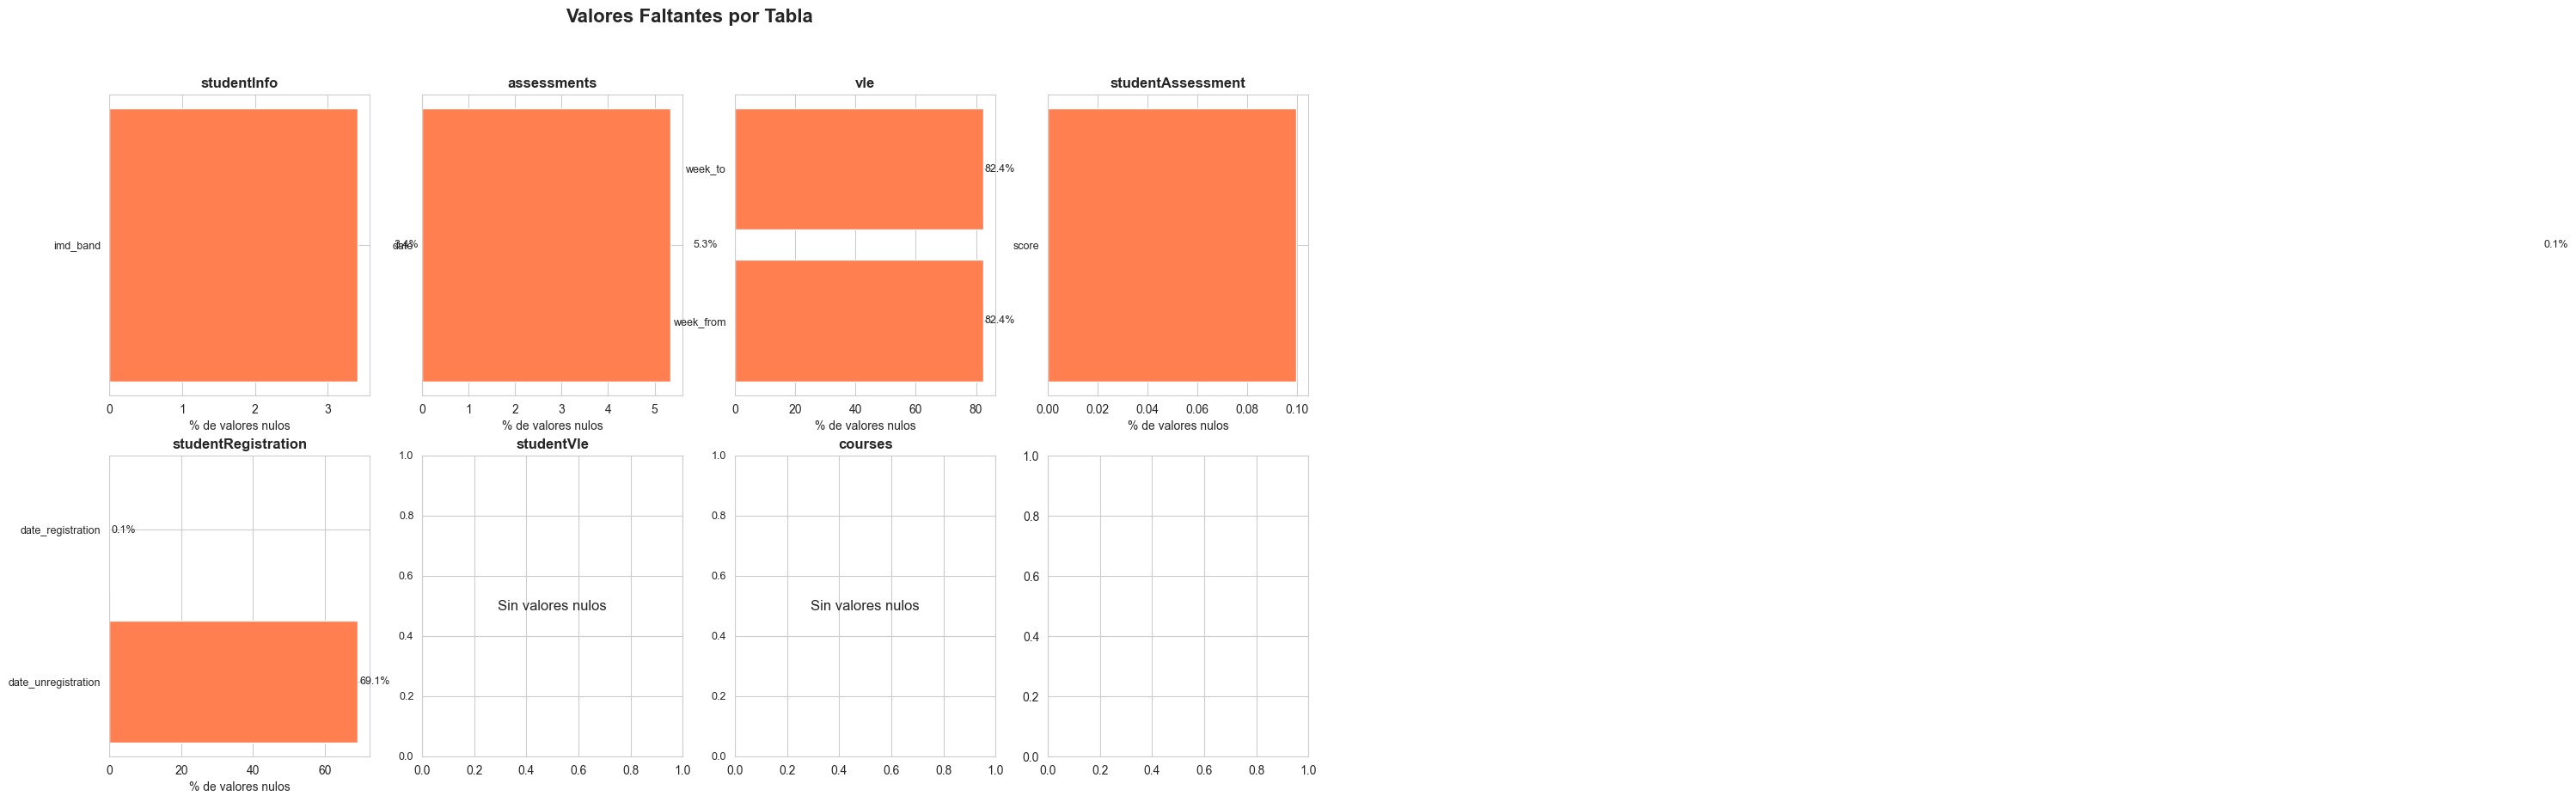


Observacion: studentVle es la tabla mas grande (~10M filas). Los valores nulos se concentran
en variables como 'date_unregistration' (ausencia = no se dio de baja) y 'imd_band' (demografico).


In [110]:
# Analisis de valores faltantes en todo el dataset

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(dataframes.items()):
    if i < len(axes):
        missing = df.isnull().sum()
        missing_pct = (missing / len(df)) * 100
        missing_df = pd.DataFrame({'Columna': missing.index, 'Nulos': missing.values, '%': missing_pct.values})
        missing_df = missing_df[missing_df['Nulos'] > 0].sort_values('Nulos', ascending=False)
        
        if len(missing_df) > 0:
            ax = axes[i]
            bars = ax.barh(missing_df['Columna'], missing_df['%'], color='coral')
            ax.set_title(f'{name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('% de valores nulos')
            for bar, pct in zip(bars, missing_df['%']):
                ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                        f'{pct:.1f}%', va='center', fontsize=9)
        else:
            axes[i].text(0.5, 0.5, 'Sin valores nulos', ha='center', va='center', fontsize=12)
            axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')
        
        axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle('Valores Faltantes por Tabla', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservacion: studentVle es la tabla mas grande (~10M filas). Los valores nulos se concentran")
print("en variables como 'date_unregistration' (ausencia = no se dio de baja) y 'imd_band' (demografico).")

---
## SECCIÓN 2: Preprocesamiento y Feature Engineering

### Estrategia de integración

Construimos un **dataset maestro** donde cada fila representa un estudiante en un curso. Para ello:

1. **studentInfo** es la tabla base (demografía + resultado final)
2. Agregamos **studentRegistration** (fechas de registro/baja)
3. Agregamos **studentVle agregado** por estudiante (total clicks, clicks por semana, etc.)
4. Agregamos **studentAssessment agregado** (promedio de notas, entregas a tiempo/tardías)

### Feature Engineering

Crearemos las siguientes variables a partir de los datos crudos:

**Features de Engagement (desde studentVle):**
- `total_clicks`: cantidad total de interacciones del estudiante
- `avg_clicks_per_week`: clicks totales / semanas del curso
- `early_activity`: proporción de clicks realizados en el primer 25% del curso
- `activity_trend`: pendiente de la regresión lineal de clicks por semana
- `unique_resources_accessed`: cantidad de recursos distintos que visitó

**Features Académicas (desde studentAssessment):**
- `mean_score`: promedio de notas obtenidas
- `submission_ratio`: proporción de evaluaciones entregadas sobre el total
- `late_submissions`: cantidad de entregas fuera de término

**Features Demográficas (desde studentInfo):**
- Variables categóricas: gender, region, highest_education, age_band, disability, imd_band
- Numéricas: num_of_prev_attempts, studied_credits

**Variable objetivo:**
- `is_withdrawn`: 1 si final_result == 'Withdrawn', 0 en caso contrario

### Decisiones de preprocesamiento

- **Encoding**: Usaremos OneHot Encoding para categóricas nominales sin orden (gender, region). Para ordinales (education, age_band) consideraremos Label Encoding si tiene sentido ordinal.
- **Escalado**: StandardScaler para todas las variables numéricas, necesario para KNN, SVM, PCA.
- **Manejo de nulos**: Imputación con mediana para numéricas, moda para categóricas.
- **Train/Test split**: 80/20 estratificado por la variable objetivo para mantener la proporción de abandono en ambos conjuntos.

In [111]:
# FEATURE ENGINEERING 1: Features de engagement desde studentVle

print("Procesando studentVle (~10M filas)...")
print("Esto puede tomar unos segundos...")

# Agregar datos del VLE (actividad por estudiante)
# 1. Total de clicks por estudiante
vle_agg = student_vle.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    unique_resources=('id_site', 'nunique'),
    days_active=('date', 'nunique')
).reset_index()

print(f"✓ studentVle agregado: {vle_agg.shape[0]} filas")

# 2. Clicks por semana (necesitamos la duracion del curso desde courses)
# Calculamos clicks semanales y tendencia
student_vle['week'] = student_vle['date'] // 7  # aproximacion: convertir dias a semanas

weekly_clicks = student_vle.groupby(
    ['id_student', 'code_module', 'code_presentation', 'week']
)['sum_click'].sum().reset_index()

# Calcular promedio de clicks por semana y tendencia
weekly_stats = weekly_clicks.groupby(
    ['id_student', 'code_module', 'code_presentation']
)['sum_click'].agg(['mean', 'std', 'max']).reset_index()
weekly_stats.columns = ['id_student', 'code_module', 'code_presentation',
                        'avg_weekly_clicks', 'std_weekly_clicks', 'max_weekly_clicks']

print(f"✓ Estadisticas semanales calculadas: {weekly_stats.shape[0]} filas")

# 3. Early activity: proporcion de clicks en el primer cuarto del curso
# Para esto necesitamos la duracion total del curso desde la tabla courses
student_vle_with_course = student_vle.merge(
    courses[['code_module', 'code_presentation', 'module_presentation_length']],
    on=['code_module', 'code_presentation'], how='left'
)

student_vle_with_course['early_cutoff'] = student_vle_with_course['module_presentation_length'] * 0.25
student_vle_with_course['is_early'] = student_vle_with_course['date'] <= student_vle_with_course['early_cutoff']

early_activity = student_vle_with_course.groupby(
    ['id_student', 'code_module', 'code_presentation']
)['is_early'].mean().reset_index()
early_activity.columns = ['id_student', 'code_module', 'code_presentation', 'early_activity_ratio']

print(f"✓ Early activity calculada: {early_activity.shape[0]} filas")

# 4. Activity trend: pendiente de clicks por semana (regresion lineal simple)
# Aproximacion simplificada: diferencia entre ultimas semanas y primeras
def compute_trend(group):
    if len(group) < 2:
        return 0
    weeks = group['week'].values
    clicks = group['sum_click'].values
    if len(np.unique(weeks)) < 2:
        return 0
    # Pendiente con formula simplificada
    n = len(weeks)
    slope = (n * np.sum(weeks * clicks) - np.sum(weeks) * np.sum(clicks)) / \
            (n * np.sum(weeks**2) - np.sum(weeks)**2)
    return slope

trend_df = weekly_clicks.groupby(
    ['id_student', 'code_module', 'code_presentation']
).apply(compute_trend).reset_index()
trend_df.columns = ['id_student', 'code_module', 'code_presentation', 'activity_trend']

print(f"✓ Activity trend calculada: {trend_df.shape[0]} filas")

# Merge de todas las features de engagement
engagement_features = vle_agg.merge(weekly_stats, on=['id_student', 'code_module', 'code_presentation'], how='left')
engagement_features = engagement_features.merge(early_activity, on=['id_student', 'code_module', 'code_presentation'], how='left')
engagement_features = engagement_features.merge(trend_df, on=['id_student', 'code_module', 'code_presentation'], how='left')

# Limpiar nulos que puedan haber quedado
engagement_features = engagement_features.fillna(0)

print(f"\n✓ Dataset de engagement completo: {engagement_features.shape[0]} filas, {engagement_features.shape[1]} columnas")
print(f"  Columnas: {list(engagement_features.columns)}")
engagement_features.head(3)

Procesando studentVle (~10M filas)...
Esto puede tomar unos segundos...
✓ studentVle agregado: 29228 filas
✓ Estadisticas semanales calculadas: 29228 filas
✓ Early activity calculada: 29228 filas
✓ Activity trend calculada: 29228 filas

✓ Dataset de engagement completo: 29228 filas, 11 columnas
  Columnas: ['id_student', 'code_module', 'code_presentation', 'total_clicks', 'unique_resources', 'days_active', 'avg_weekly_clicks', 'std_weekly_clicks', 'max_weekly_clicks', 'early_activity_ratio', 'activity_trend']


,id_student,code_module,code_presentation,total_clicks,unique_resources,days_active,avg_weekly_clicks,std_weekly_clicks,max_weekly_clicks,early_activity_ratio,activity_trend
0,6516,AAA,2014J,2791,84,159,71.564103,52.76402,229,0.36858,-0.379975
1,8462,DDD,2013J,646,125,56,38.000000,39.68312,146,0.75000,-4.525866
2,8462,DDD,2014J,10,3,1,10.000000,0.00000,10,1.00000,0.000000


In [112]:
# FEATURE ENGINEERING 2: Features academicas desde studentAssessment

print("Procesando studentAssessment...")

# Merge con assessments para obtener informacion de cada evaluacion (peso, fecha tope)
assess_full = student_assessment.merge(
    assessments[['id_assessment', 'date', 'weight', 'assessment_type']],
    on='id_assessment', how='left'
)

# Necesitamos code_module y code_presentation desde assessments
assess_full = assess_full.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation']],
    on='id_assessment', how='left'
)

print(f"  Total registros de evaluaciones: {assess_full.shape[0]}")

# 1. Promedio de notas por estudiante
academic_agg = assess_full.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    mean_score=('score', 'mean'),
    max_score=('score', 'max'),
    min_score=('score', 'min'),
    std_score=('score', 'std'),
    num_assessments=('id_assessment', 'nunique')
).reset_index()

print(f"✓ Estadisticas de notas calculadas")

# 2. Late submissions: entregas despues de la fecha
assess_full['is_late'] = assess_full['date_submitted'] > assess_full['date']
late_info = assess_full.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    late_submissions=('is_late', 'sum'),
    submission_ratio=('date_submitted', 'count')  # seran corregidos luego
).reset_index()

# submission_ratio: proporcion de evaluaciones entregadas sobre las asignadas
# Primero, contar cuantas evaluaciones tiene cada curso
assessments_per_course = assessments.groupby(
    ['code_module', 'code_presentation']
)['id_assessment'].count().reset_index()
assessments_per_course.columns = ['code_module', 'code_presentation', 'total_assessments']

academic_features = academic_agg.merge(late_info, on=['id_student', 'code_module', 'code_presentation'], how='left')
academic_features = academic_features.merge(
    assessments_per_course, on=['code_module', 'code_presentation'], how='left'
)

academic_features['submission_ratio'] = academic_features['num_assessments'] / academic_features['total_assessments']
academic_features['late_submissions'] = academic_features['late_submissions'].fillna(0).astype(int)

print(f"✓ Late submissions y submission ratio calculados")

# Limpiar nulos
academic_features['std_score'] = academic_features['std_score'].fillna(0)

print(f"\n✓ Dataset academico completo: {academic_features.shape[0]} filas, {academic_features.shape[1]} columnas")
print(f"  Columnas: {list(academic_features.columns)}")
academic_features.head(3)

Procesando studentAssessment...
  Total registros de evaluaciones: 173912
✓ Estadisticas de notas calculadas
✓ Late submissions y submission ratio calculados

✓ Dataset academico completo: 25843 filas, 11 columnas
  Columnas: ['id_student', 'code_module', 'code_presentation', 'mean_score', 'max_score', 'min_score', 'std_score', 'num_assessments', 'late_submissions', 'submission_ratio', 'total_assessments']


,id_student,code_module,code_presentation,mean_score,max_score,min_score,std_score,num_assessments,late_submissions,submission_ratio,total_assessments
0,6516,AAA,2014J,61.800000,77.0,48.0,10.329569,5,0,0.833333,6
1,8462,DDD,2013J,87.666667,93.0,83.0,5.033223,3,1,0.428571,7
2,8462,DDD,2014J,86.500000,93.0,83.0,4.725816,4,0,0.571429,7


In [113]:
# CONSTRUCCION DEL DATASET MAESTRO

print("Construyendo dataset maestro...")

# Paso 1: Partir de studentInfo (tabla base)
master = student_info.copy()
print(f"Paso 1 - Base (studentInfo): {master.shape[0]} filas")

# Paso 2: Merge con studentRegistration
master = master.merge(
    student_registration[['id_student', 'code_module', 'code_presentation',
                          'date_registration', 'date_unregistration']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)
print(f"Paso 2 - + Registration: {master.shape[0]} filas")

# Paso 3: Merge con engagement features
master = master.merge(
    engagement_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)
print(f"Paso 3 - + Engagement: {master.shape[0]} filas")

# Paso 4: Merge con academic features
master = master.merge(
    academic_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)
print(f"Paso 4 - + Academic: {master.shape[0]} filas")

# Paso 5: Merge con courses para duracion del curso
master = master.merge(
    courses[['code_module', 'code_presentation', 'module_presentation_length']],
    on=['code_module', 'code_presentation'],
    how='left'
)
print(f"Paso 5 - + Courses: {master.shape[0]} filas")

print(f"\n{'='*60}")
print(f"DATASET MAESTRO FINAL: {master.shape[0]} filas, {master.shape[1]} columnas")
print(f"{'='*60}")
master.head(3)

Construyendo dataset maestro...
Paso 1 - Base (studentInfo): 32593 filas
Paso 2 - + Registration: 32593 filas
Paso 3 - + Engagement: 32593 filas
Paso 4 - + Academic: 32593 filas
Paso 5 - + Courses: 32593 filas

DATASET MAESTRO FINAL: 32593 filas, 31 columnas


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,activity_trend,mean_score,max_score,min_score,std_score,num_assessments,late_submissions,submission_ratio,total_assessments,module_presentation_length
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,-1.295345,82.0,85.0,78.0,3.082207,5.0,0.0,0.833333,6.0,268
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,-1.584412,66.4,70.0,60.0,4.335897,5.0,2.0,0.833333,6.0,268
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,19.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,268


In [114]:
# MANEJO DE VALORES FALTANTES EN EL DATASET MAESTRO

print("Valores faltantes en el dataset maestro:")
missing = master.isnull().sum()
missing_pct = (missing / len(master)) * 100
missing_df = pd.DataFrame({'Nulos': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
else:
    print("  No hay valores faltantes.")

# Estrategia de imputacion:
# - 'date_unregistration': los que no se dieron de baja -> NaN, lo tratamos como 0 (nunca se fueron)
master['date_unregistration'] = master['date_unregistration'].fillna(0).astype(int)

# - 'imd_band': categorico, imputar con la moda
master['imd_band'] = master['imd_band'].fillna(master['imd_band'].mode()[0])

# - 'date_registration': si es NaN, imputar con la mediana
master['date_registration'] = master['date_registration'].fillna(master['date_registration'].median()).astype(int)

# Verificar que no queden nulos
remaining_nulls = master.isnull().sum().sum()
print(f"\nValores nulos restantes: {remaining_nulls}")

if remaining_nulls > 0:
    # Imputar el resto con valores apropiados
    for col in master.columns:
        if master[col].isnull().sum() > 0:
            if master[col].dtype == 'object':
                master[col] = master[col].fillna('Unknown')
            else:
                master[col] = master[col].fillna(master[col].median())

print(f"Valores nulos despues de imputacion: {master.isnull().sum().sum()}")
print("\n✓ Dataset maestro limpio y listo.")

Valores faltantes en el dataset maestro:


,Nulos,%
date_unregistration,22521,69.097659
min_score,6773,20.780536
max_score,6773,20.780536
mean_score,6773,20.780536
submission_ratio,6750,20.709968
std_score,6750,20.709968
total_assessments,6750,20.709968
late_submissions,6750,20.709968
num_assessments,6750,20.709968
activity_trend,3365,10.324303



Valores nulos restantes: 80989
Valores nulos despues de imputacion: 0

✓ Dataset maestro limpio y listo.


Distribucion de final_result:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Proporcion:
final_result
Pass           37.9
Withdrawn      31.2
Fail           21.6
Distinction     9.3
Name: proportion, dtype: float64

Variable objetivo 'is_withdrawn':
is_withdrawn
0    22437
1    10156
Name: count, dtype: int64

Proporcion de abandono: 31.2%


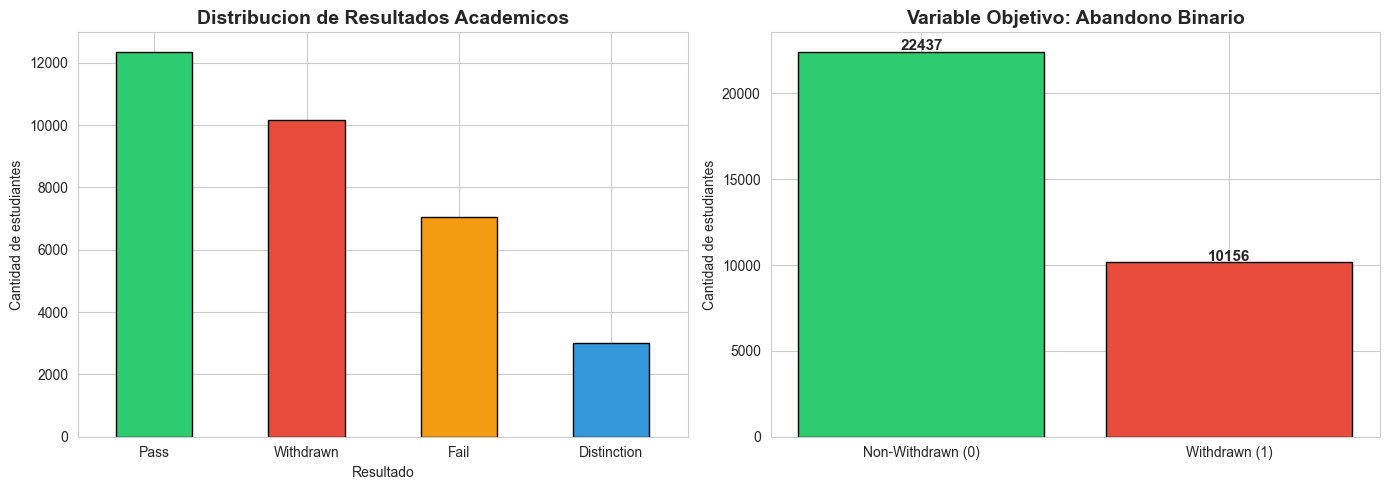


Observacion: Hay desbalance de clases. La mayoria de estudiantes no abandonan.
Esto es importante para la evaluacion de modelos (accuracy puede ser enganosa).


In [115]:
# DEFINICION DE LA VARIABLE OBJETIVO

print("Distribucion de final_result:")
print(master['final_result'].value_counts())
print(f"\nProporcion:\n{master['final_result'].value_counts(normalize=True).mul(100).round(1)}")

# Crear variable objetivo binaria: Withdrawn (1) vs Non-Withdrawn (0)
master['is_withdrawn'] = (master['final_result'] == 'Withdrawn').astype(int)

print(f"\nVariable objetivo 'is_withdrawn':")
print(master['is_withdrawn'].value_counts())
print(f"\nProporcion de abandono: {master['is_withdrawn'].mean()*100:.1f}%")

# Visualizar distribucion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Distribucion completa de final_result
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
master['final_result'].value_counts().plot(kind='bar', ax=axes[0], color=colors[:4], edgecolor='black')
axes[0].set_title('Distribucion de Resultados Academicos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Resultado')
axes[0].set_ylabel('Cantidad de estudiantes')
axes[0].tick_params(axis='x', rotation=0)

# Grafico 2: Objetivo binario
binary_counts = master['is_withdrawn'].value_counts()
bars = axes[1].bar(['Non-Withdrawn (0)', 'Withdrawn (1)'], binary_counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Variable Objetivo: Abandono Binario', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cantidad de estudiantes')
for bar, val in zip(bars, binary_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(val), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nObservacion: Hay desbalance de clases. La mayoria de estudiantes no abandonan.")
print("Esto es importante para la evaluacion de modelos (accuracy puede ser enganosa).")

---
## SECCION 3: Auditoria de Leakage

Antes de entrenar modelos revisamos que variables estarian disponibles realmente al momento de emitir una alerta temprana.

Esta seccion es clave porque un modelo puede parecer excelente si usa informacion del futuro, pero ese rendimiento no seria defendible en produccion.

In [116]:
# AUDITORIA DE LEAKAGE

leakage_audit = pd.DataFrame([
    {
        'Feature / fuente': 'final_result',
        'Riesgo de leakage': 'Alto',
        'Motivo': 'Es el resultado final usado para construir el target.',
        'Accion tomada': 'Se elimina de las features.'
    },
    {
        'Feature / fuente': 'date_unregistration',
        'Riesgo de leakage': 'Alto',
        'Motivo': 'Indica explicitamente la baja del estudiante.',
        'Accion tomada': 'Se excluye del modelado predictivo.'
    },
    {
        'Feature / fuente': 'mean_score, max_score, submission_ratio full-course',
        'Riesgo de leakage': 'Medio/Alto',
        'Motivo': 'Si se calculan con todo el curso incorporan informacion posterior a la alerta.',
        'Accion tomada': 'Se recalculan por snapshot temporal: semanas 2, 4 y 6.'
    },
    {
        'Feature / fuente': 'total_clicks full-course',
        'Riesgo de leakage': 'Medio',
        'Motivo': 'Clicks posteriores a la semana de alerta no estarian disponibles.',
        'Accion tomada': 'Se recalculan acumulados hasta cada semana.'
    },
    {
        'Feature / fuente': 'Variables demograficas y de inscripcion',
        'Riesgo de leakage': 'Bajo',
        'Motivo': 'Estan disponibles al inicio del curso.',
        'Accion tomada': 'Se mantienen, excluyendo date_unregistration.'
    },
], columns=['Feature / fuente', 'Riesgo de leakage', 'Motivo', 'Accion tomada'])

display(leakage_audit)

print("Decision metodologica:")
print("- El dataset maestro se conserva para EDA descriptivo.")
print("- El modelado supervisado usa snapshots temporales, no agregados del curso completo.")
print("- Encoding, imputacion y escalado se ajustan solo con train mediante Pipelines.")

,Feature / fuente,Riesgo de leakage,Motivo,Accion tomada
0,final_result,Alto,Es el resultado final usado para construir el ...,Se elimina de las features.
1,date_unregistration,Alto,Indica explicitamente la baja del estudiante.,Se excluye del modelado predictivo.
2,"mean_score, max_score, submission_ratio full-c...",Medio/Alto,Si se calculan con todo el curso incorporan in...,Se recalculan por snapshot temporal: semanas 2...
3,total_clicks full-course,Medio,Clicks posteriores a la semana de alerta no es...,Se recalculan acumulados hasta cada semana.
4,Variables demograficas y de inscripcion,Bajo,Estan disponibles al inicio del curso.,"Se mantienen, excluyendo date_unregistration."


Decision metodologica:
- El dataset maestro se conserva para EDA descriptivo.
- El modelado supervisado usa snapshots temporales, no agregados del curso completo.
- Encoding, imputacion y escalado se ajustan solo con train mediante Pipelines.


---
## SECCION 4: Construccion Temporal del Dataset

Convertimos el problema en un **Early Warning System**. En lugar de predecir abandono con informacion de todo el curso, generamos tres cortes temporales:

- Semana 2
- Semana 4
- Semana 6

Cada snapshot contiene solo actividad y evaluaciones disponibles hasta ese momento.

In [117]:
# FUNCIONES MODULARES PARA SNAPSHOTS TEMPORALES

KEYS = ['id_student', 'code_module', 'code_presentation']
SNAPSHOT_WEEKS = [2, 4, 6]


def build_temporal_features(week):
    """Construye features disponibles hasta la semana indicada."""
    cutoff_day = week * 7

    base = student_info.merge(
        student_registration[KEYS + ['date_registration']],
        on=KEYS,
        how='left'
    ).merge(
        courses[['code_module', 'code_presentation', 'module_presentation_length']],
        on=['code_module', 'code_presentation'],
        how='left'
    )

    # Engagement acumulado hasta el corte temporal.
    vle_until = student_vle[student_vle['date'] <= cutoff_day].copy()
    vle_until['week_observed'] = np.floor(vle_until['date'] / 7).astype(int)

    engagement = vle_until.groupby(KEYS).agg(
        clicks_until_week=('sum_click', 'sum'),
        unique_resources_until_week=('id_site', 'nunique'),
        active_days_until_week=('date', 'nunique'),
        active_weeks_until_week=('week_observed', 'nunique'),
        last_activity_day=('date', 'max')
    ).reset_index()

    recent = vle_until[vle_until['date'] > cutoff_day - 7].groupby(KEYS)['sum_click'].sum().reset_index()
    recent.columns = KEYS + ['clicks_last_7_days']

    previous = vle_until[(vle_until['date'] <= cutoff_day - 7) & (vle_until['date'] > cutoff_day - 14)].groupby(KEYS)['sum_click'].sum().reset_index()
    previous.columns = KEYS + ['clicks_previous_7_days']

    engagement = engagement.merge(recent, on=KEYS, how='left').merge(previous, on=KEYS, how='left')
    engagement[['clicks_last_7_days', 'clicks_previous_7_days']] = engagement[['clicks_last_7_days', 'clicks_previous_7_days']].fillna(0)
    engagement['activity_delta_7_days'] = engagement['clicks_last_7_days'] - engagement['clicks_previous_7_days']
    engagement['avg_clicks_per_active_week'] = engagement['clicks_until_week'] / engagement['active_weeks_until_week'].replace(0, np.nan)

    # Evaluaciones disponibles hasta el corte: solo entregas realizadas hasta esa fecha.
    submitted_until = assess_full[assess_full['date_submitted'] <= cutoff_day].copy()
    submitted_until['is_late_until_week'] = submitted_until['date_submitted'] > submitted_until['date']

    academic = submitted_until.groupby(KEYS).agg(
        mean_score_until_week=('score', 'mean'),
        max_score_until_week=('score', 'max'),
        min_score_until_week=('score', 'min'),
        submitted_assessments_until_week=('id_assessment', 'nunique'),
        late_submissions_until_week=('is_late_until_week', 'sum')
    ).reset_index()

    due_until = assessments[assessments['date'] <= cutoff_day].groupby(
        ['code_module', 'code_presentation']
    )['id_assessment'].nunique().reset_index()
    due_until.columns = ['code_module', 'code_presentation', 'assessments_due_until_week']

    snapshot = base.merge(engagement, on=KEYS, how='left')
    snapshot = snapshot.merge(academic, on=KEYS, how='left')
    snapshot = snapshot.merge(due_until, on=['code_module', 'code_presentation'], how='left')

    numeric_fill_zero = [
        'clicks_until_week', 'unique_resources_until_week', 'active_days_until_week',
        'active_weeks_until_week', 'last_activity_day', 'clicks_last_7_days',
        'clicks_previous_7_days', 'activity_delta_7_days', 'avg_clicks_per_active_week',
        'mean_score_until_week', 'max_score_until_week', 'min_score_until_week',
        'submitted_assessments_until_week', 'late_submissions_until_week',
        'assessments_due_until_week'
    ]
    for col in numeric_fill_zero:
        if col in snapshot.columns:
            snapshot[col] = snapshot[col].fillna(0)

    snapshot['submission_ratio_until_week'] = (
        snapshot['submitted_assessments_until_week'] /
        snapshot['assessments_due_until_week'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    snapshot['is_withdrawn'] = (snapshot['final_result'] == 'Withdrawn').astype(int)
    snapshot['snapshot_week'] = week
    snapshot['presentation_year'] = snapshot['code_presentation'].str.extract(r'(\d{4})').astype(int)

    return snapshot


def build_preprocessor(X):
    """Crea transformaciones para numericas y categoricas sin ajustar con test."""
    numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )


def split_features_target(df):
    """Separa features y target excluyendo identificadores y variables con leakage."""
    drop_cols = [
        'is_withdrawn', 'final_result', 'id_student',
        'date_unregistration'  # no deberia existir en snapshots, queda como proteccion
    ]
    X = df.drop(columns=drop_cols, errors='ignore')
    y = df['is_withdrawn']
    return X, y


def evaluate_predictions(y_true, y_pred, y_proba):
    """Calcula metricas orientadas al problema de abandono."""
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }


temporal_datasets = {week: build_temporal_features(week) for week in SNAPSHOT_WEEKS}

for week, df_week in temporal_datasets.items():
    print(f"Semana {week}: {df_week.shape[0]} estudiantes | abandono = {df_week['is_withdrawn'].mean()*100:.1f}%")
    display(df_week.head(3))

Semana 2: 32593 estudiantes | abandono = 31.2%


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,mean_score_until_week,max_score_until_week,min_score_until_week,submitted_assessments_until_week,late_submissions_until_week,assessments_due_until_week,submission_ratio_until_week,is_withdrawn,snapshot_week,presentation_year
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2,2013
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2,2013
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,2013


Semana 4: 32593 estudiantes | abandono = 31.2%


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,mean_score_until_week,max_score_until_week,min_score_until_week,submitted_assessments_until_week,late_submissions_until_week,assessments_due_until_week,submission_ratio_until_week,is_withdrawn,snapshot_week,presentation_year
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,78.0,78.0,78.0,1.0,0.0,1.0,1.0,0,4,2013
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,70.0,70.0,70.0,1.0,1.0,1.0,1.0,0,4,2013
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,4,2013


Semana 6: 32593 estudiantes | abandono = 31.2%


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,mean_score_until_week,max_score_until_week,min_score_until_week,submitted_assessments_until_week,late_submissions_until_week,assessments_due_until_week,submission_ratio_until_week,is_withdrawn,snapshot_week,presentation_year
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,78.0,78.0,78.0,1.0,0.0,1.0,1.0,0,6,2013
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,70.0,70.0,70.0,1.0,1.0,1.0,1.0,0,6,2013
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,6,2013


In [ ]:
# MATRIZ EXPLORATORIA SEGURA PARA PCA Y CLUSTERING

# Usamos el snapshot de semana 6 como representacion temprana mas informativa.
# Esta matriz no se usa para reportar metricas finales; las metricas supervisadas se calculan con pipelines por split.
exploratory_snapshot = temporal_datasets[6].copy()
X_exploratory_raw, y = split_features_target(exploratory_snapshot)

exploratory_preprocessor = build_preprocessor(X_exploratory_raw)
X_final_array = exploratory_preprocessor.fit_transform(X_exploratory_raw)
feature_names = exploratory_preprocessor.get_feature_names_out()
feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

X_final = pd.DataFrame(X_final_array, columns=feature_names, index=exploratory_snapshot.index)

print(f"Dataset exploratorio temprano: {X_final.shape[0]} filas, {X_final.shape[1]} features")
print(f"Target abandono: {y.mean()*100:.1f}%")
print("X_final queda disponible para PCA y K-Means sin usar date_unregistration ni final_result.")

Dataset exploratorio temprano: 32593 filas, 68 features
Target abandono: 31.2%
? X_final queda disponible para PCA y K-Means sin usar date_unregistration ni final_result.


In [119]:
# SPLIT ALEATORIO SOLO COMO BASELINE DESCRIPTIVO

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Baseline random split - Train: {X_train.shape[0]} muestras ({y_train.mean()*100:.1f}% abandono)")
print(f"Baseline random split - Test:  {X_test.shape[0]} muestras ({y_test.mean()*100:.1f}% abandono)")
print("Nota metodologica: la evaluacion principal se realiza mas abajo con split temporal 2013 -> 2014.")

Baseline random split - Train: 26074 muestras (31.2% abandono)
Baseline random split - Test:  6519 muestras (31.2% abandono)
Nota metodologica: la evaluacion principal se realiza mas abajo con split temporal 2013 -> 2014.


---
## SECCIÓN 3: Análisis Exploratorio de Datos (EDA)

### Preguntas que buscamos responder:

1. ¿Qué factores demográficos se asocian con el abandono?
2. ¿Los estudiantes que abandonan tienen menor actividad en la plataforma?
3. ¿Existe relación entre las calificaciones obtenidas y la probabilidad de abandono?
4. ¿Hay patrones temporales en la actividad de los estudiantes?
5. ¿Qué variables están más correlacionadas con el abandono?

El EDA nos permitirá generar hipótesis y validar que las features construidas tengan poder predictivo.

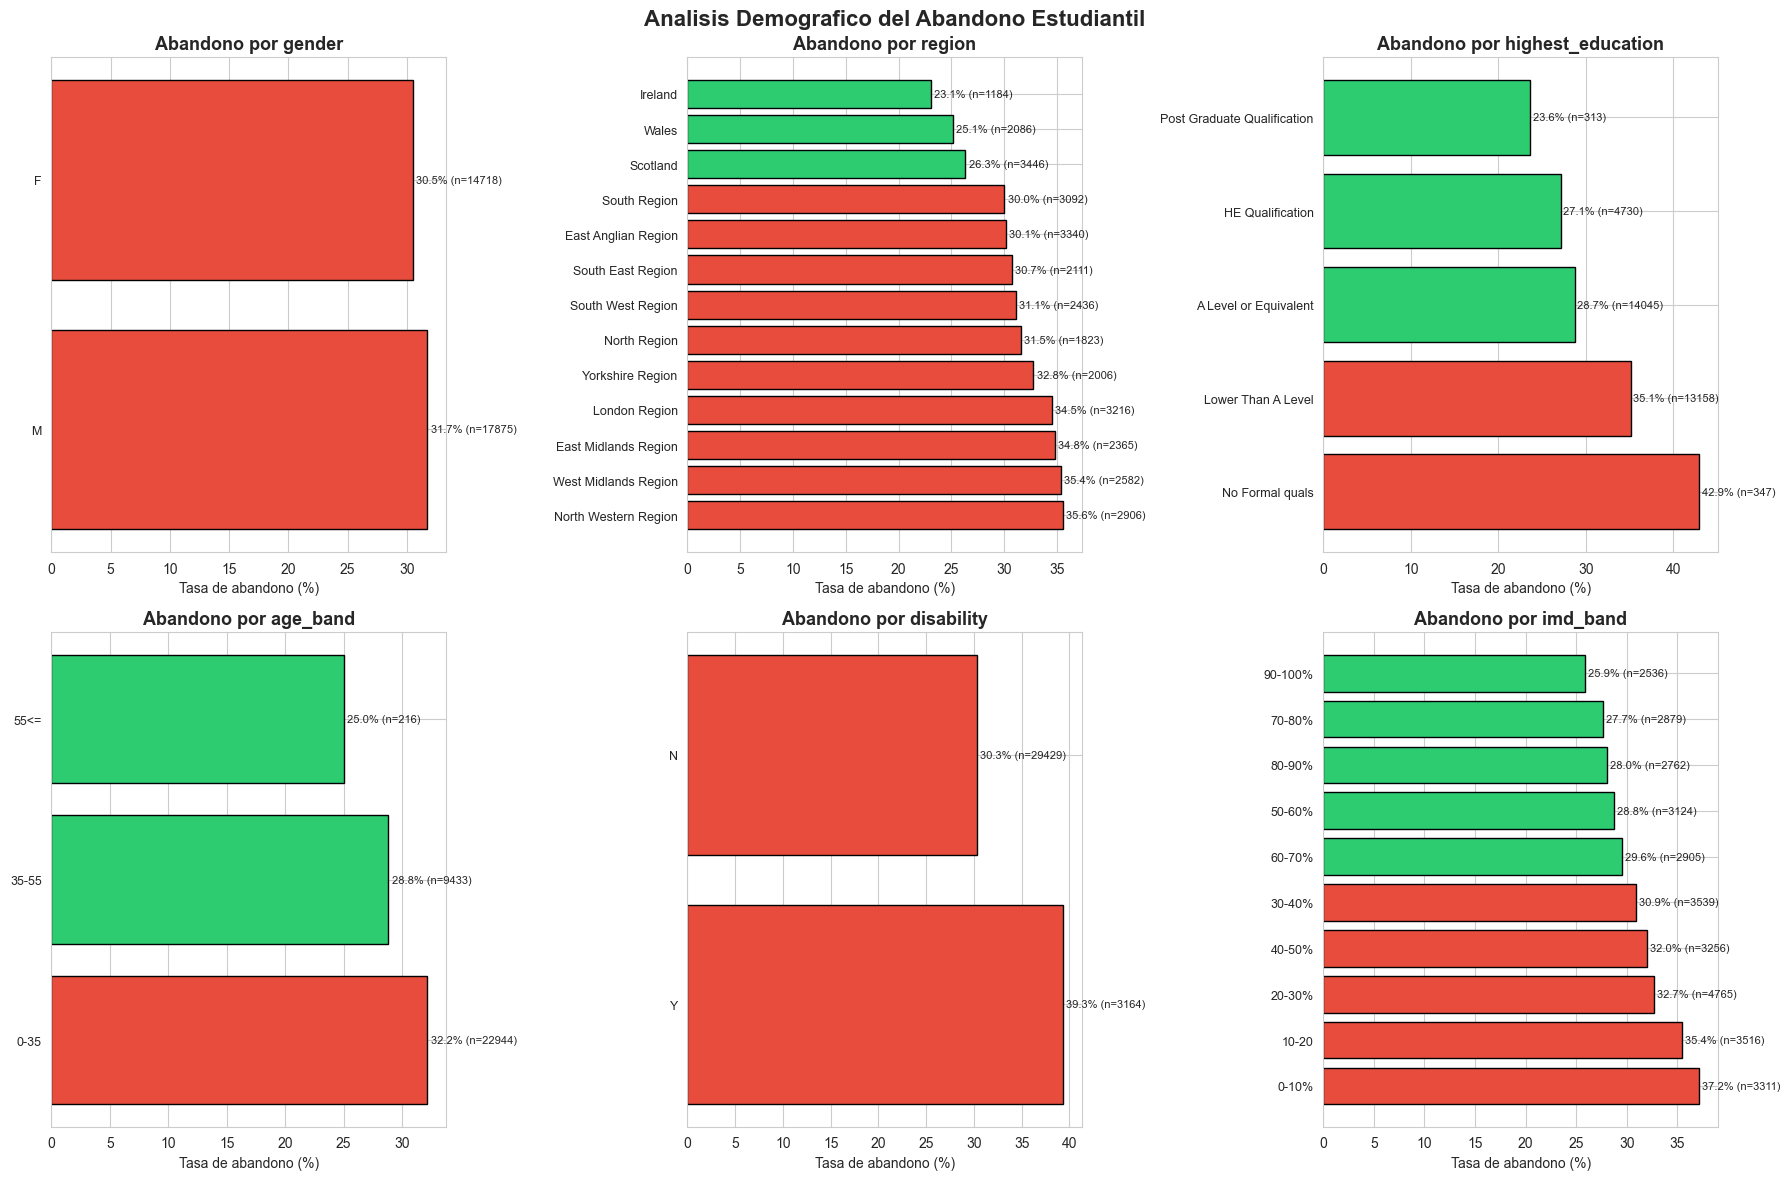


--- Hallazgos demograficos ---
• El rango etario '55<=' muestra mayor tasa de abandono.
• Los estudiantes con discapacidad (disability='Y') tienden a abandonar mas.
• El nivel educativo previo influye: menor educacion formal → mayor abandono.


In [120]:
# EDA 1: Analisis demografico vs abandono

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

demographic_cols = ['gender', 'region', 'highest_education', 'age_band', 'disability', 'imd_band']

for i, col in enumerate(demographic_cols):
    if col in master.columns:
        # Calcular tasa de abandono por categoria
        grouped = master.groupby(col)['is_withdrawn'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        
        ax = axes[i]
        colors = ['#e74c3c' if v > 0.3 else '#2ecc71' for v in grouped['mean']]
        bars = ax.barh(range(len(grouped)), grouped['mean']*100, color=colors, edgecolor='black')
        ax.set_yticks(range(len(grouped)))
        ax.set_yticklabels(grouped.index, fontsize=9)
        ax.set_xlabel('Tasa de abandono (%)')
        ax.set_title(f'Abandono por {col}', fontsize=13, fontweight='bold')
        
        for bar, (_, row) in zip(bars, grouped.iterrows()):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{bar.get_width():.1f}% (n={int(row["count"])})', va='center', fontsize=8)

plt.suptitle('Analisis Demografico del Abandono Estudiantil', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- Hallazgos demograficos ---")
print("• El rango etario '55<=' muestra mayor tasa de abandono.")
print("• Los estudiantes con discapacidad (disability='Y') tienden a abandonar mas.")
print("• El nivel educativo previo influye: menor educacion formal → mayor abandono.")

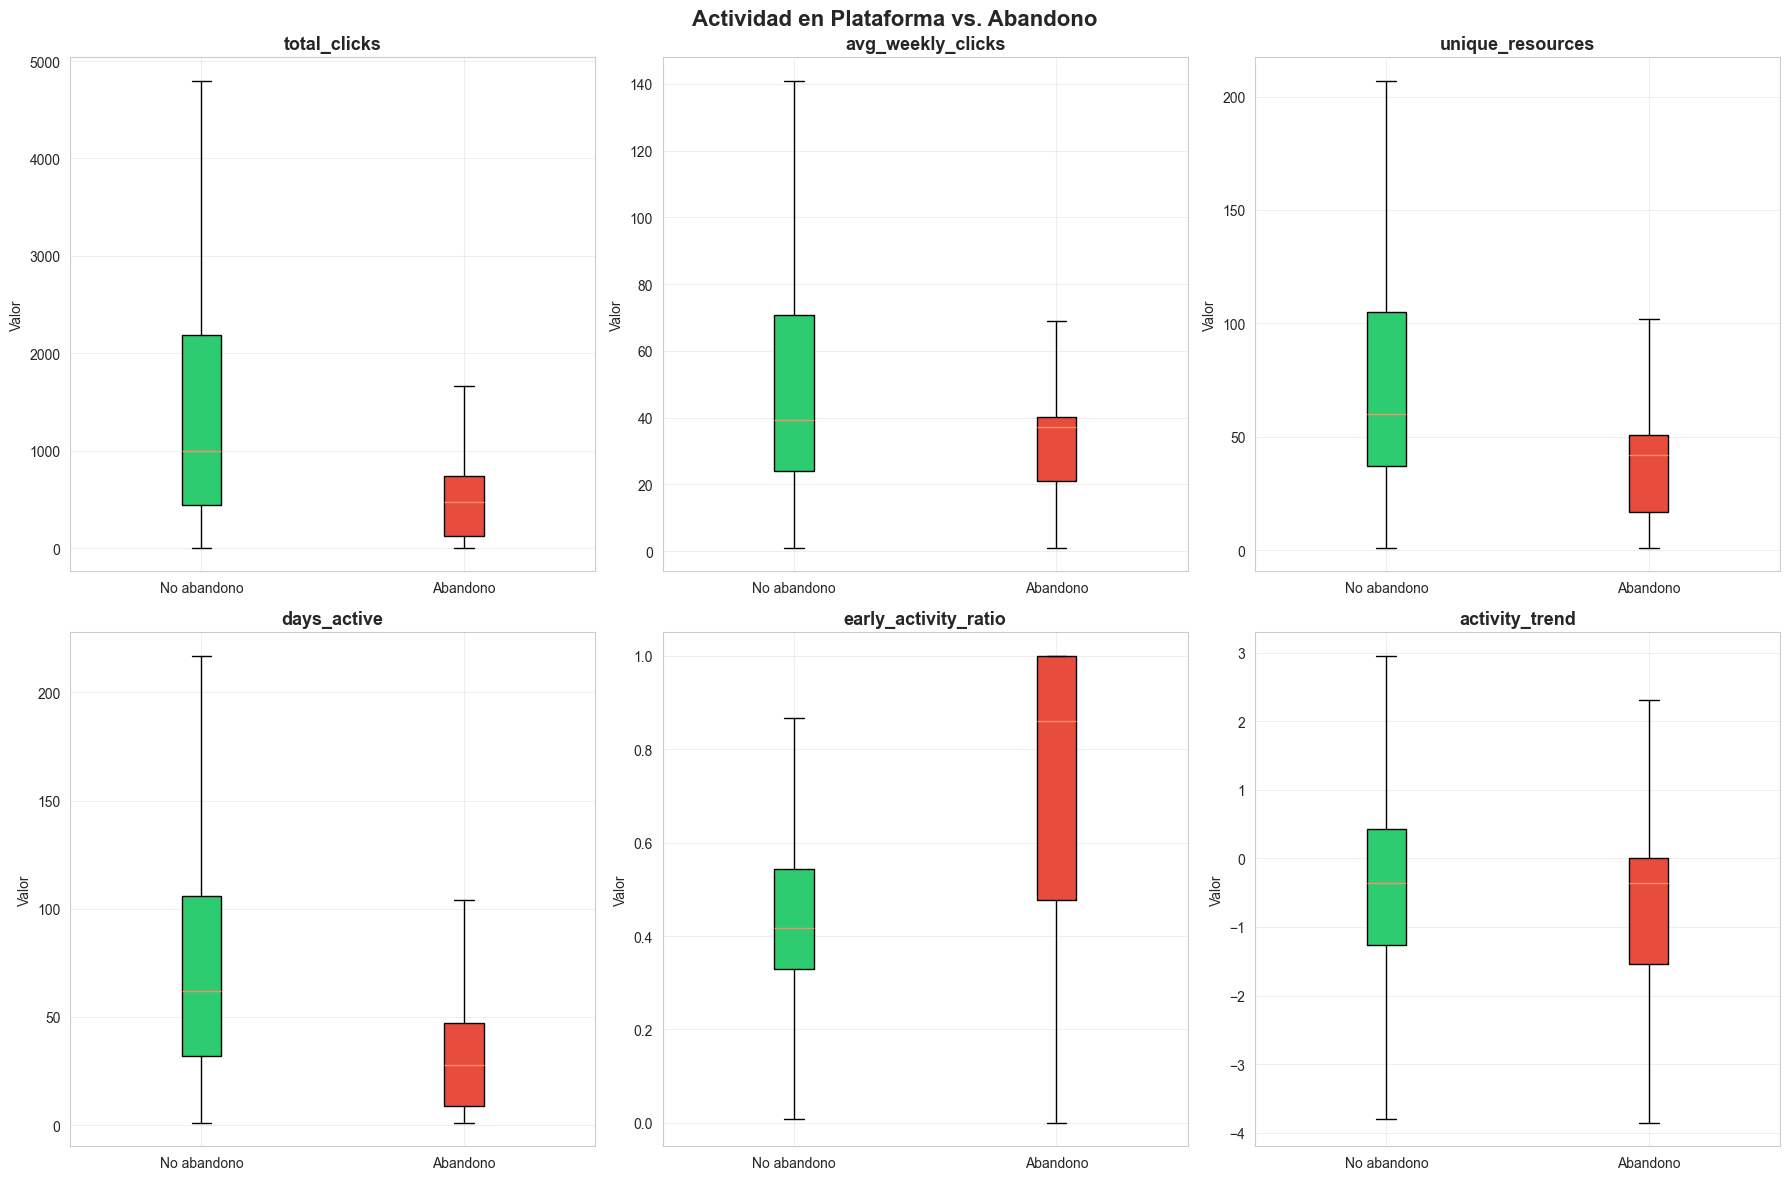


--- Hallazgos de engagement ---
• Los estudiantes que abandonan tienen significativamente menos clicks totales.
• La actividad temprana (early_activity_ratio) es menor en quienes abandonan.
• El activity_trend tiende a ser negativo en abandonos (actividad decreciente).


In [121]:
# EDA 2: Actividad en plataforma vs abandono

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

engagement_vars = ['total_clicks', 'avg_weekly_clicks', 'unique_resources',
                   'days_active', 'early_activity_ratio', 'activity_trend']

for i, var in enumerate(engagement_vars):
    if var in master.columns:
        ax = axes[i]
        
        # Separar por grupo de abandono
        withdrawn = master[master['is_withdrawn'] == 1][var].dropna()
        non_withdrawn = master[master['is_withdrawn'] == 0][var].dropna()
        
        # Boxplot
        bp = ax.boxplot([non_withdrawn, withdrawn], labels=['No abandono', 'Abandono'],
                        patch_artist=True, showfliers=False)
        bp['boxes'][0].set_facecolor('#2ecc71')
        bp['boxes'][1].set_facecolor('#e74c3c')
        ax.set_title(f'{var}', fontsize=13, fontweight='bold')
        ax.set_ylabel('Valor')
        ax.grid(True, alpha=0.3)

plt.suptitle('Actividad en Plataforma vs. Abandono', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- Hallazgos de engagement ---")
print("• Los estudiantes que abandonan tienen significativamente menos clicks totales.")
print("• La actividad temprana (early_activity_ratio) es menor en quienes abandonan.")
print("• El activity_trend tiende a ser negativo en abandonos (actividad decreciente).")

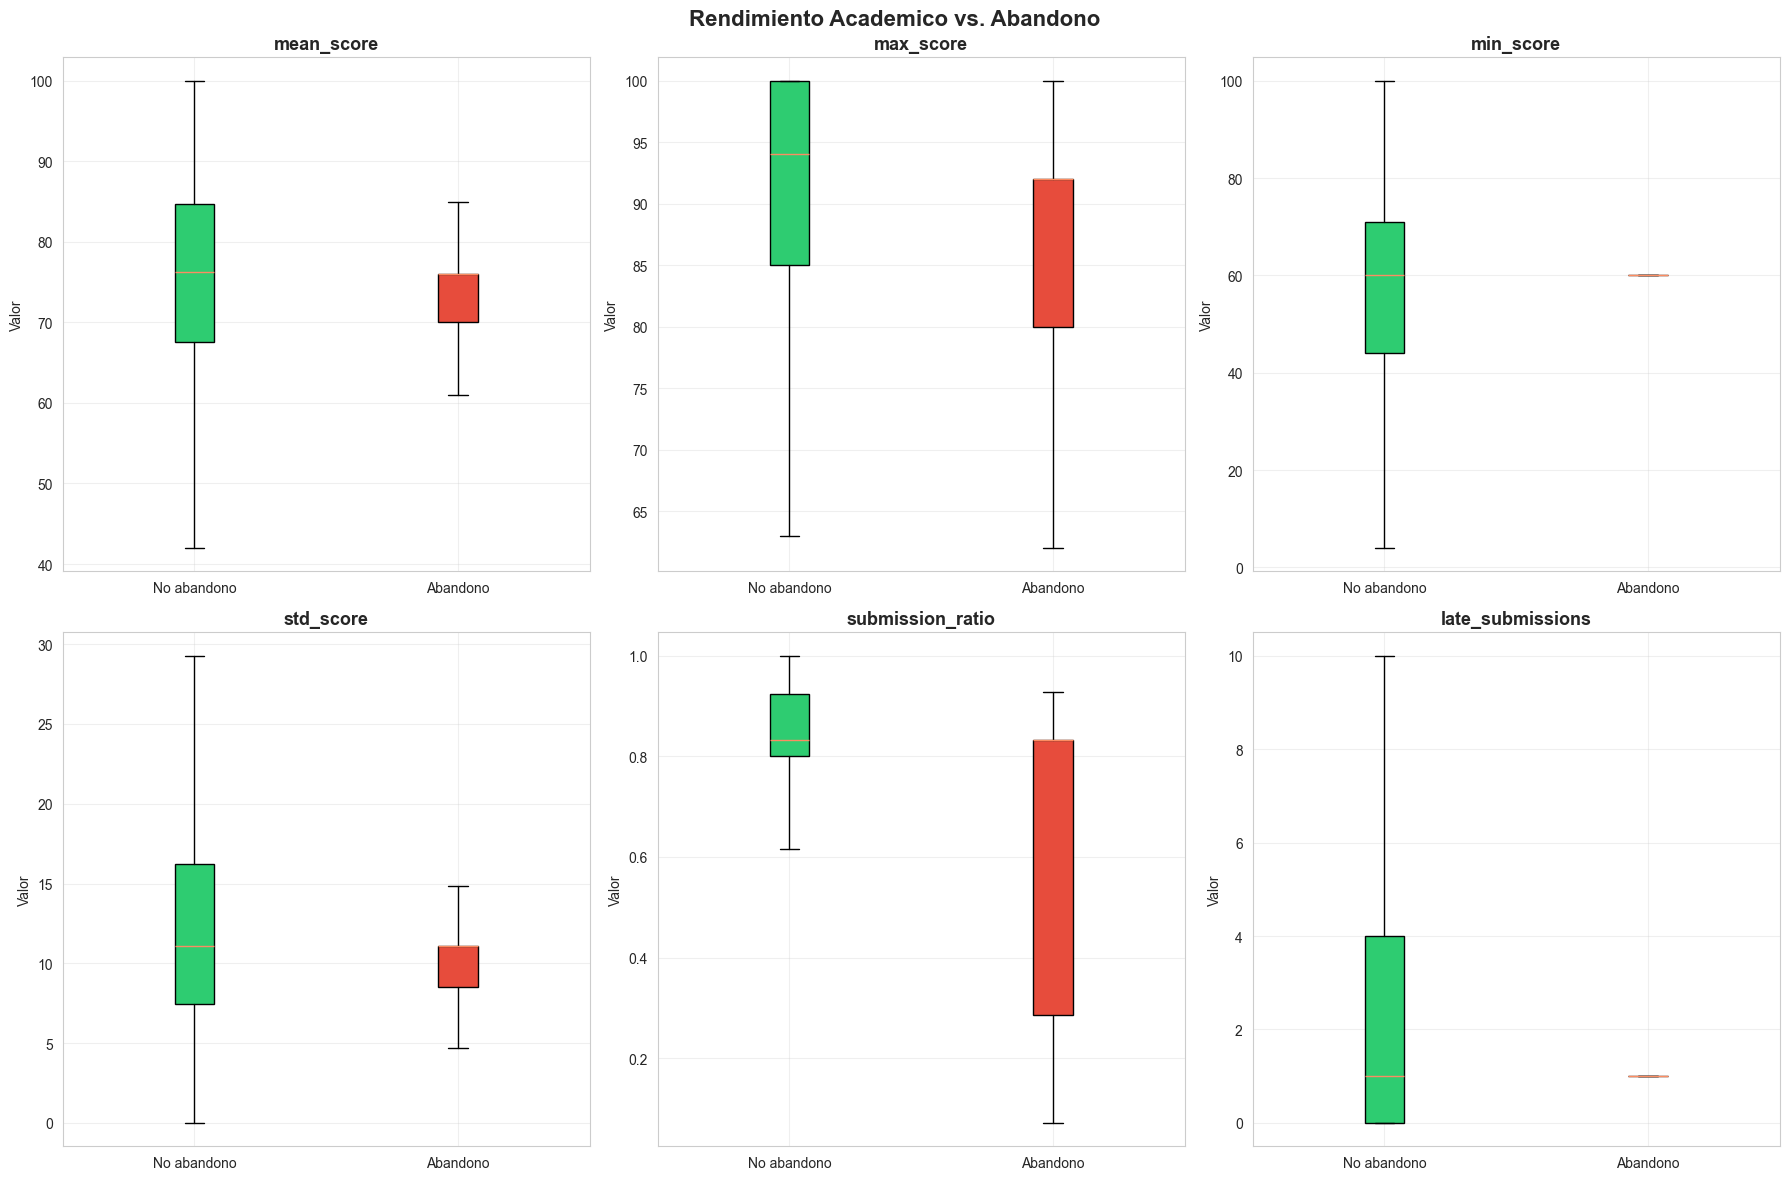


--- Hallazgos academicos ---
• El promedio de notas (mean_score) es drasticamente menor en quienes abandonan.
• La proporcion de entregas (submission_ratio) es menor en abandonos.
• Las entregas tardias (late_submissions) no son necesariamente indicativas por si solas.


In [122]:
# EDA 3: Rendimiento academico vs abandono

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

academic_vars = ['mean_score', 'max_score', 'min_score', 'std_score',
                 'submission_ratio', 'late_submissions']

for i, var in enumerate(academic_vars):
    if var in master.columns:
        ax = axes[i]
        
        withdrawn = master[master['is_withdrawn'] == 1][var].dropna()
        non_withdrawn = master[master['is_withdrawn'] == 0][var].dropna()
        
        bp = ax.boxplot([non_withdrawn, withdrawn], labels=['No abandono', 'Abandono'],
                        patch_artist=True, showfliers=False)
        bp['boxes'][0].set_facecolor('#2ecc71')
        bp['boxes'][1].set_facecolor('#e74c3c')
        ax.set_title(f'{var}', fontsize=13, fontweight='bold')
        ax.set_ylabel('Valor')
        ax.grid(True, alpha=0.3)

plt.suptitle('Rendimiento Academico vs. Abandono', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- Hallazgos academicos ---")
print("• El promedio de notas (mean_score) es drasticamente menor en quienes abandonan.")
print("• La proporcion de entregas (submission_ratio) es menor en abandonos.")
print("• Las entregas tardias (late_submissions) no son necesariamente indicativas por si solas.")

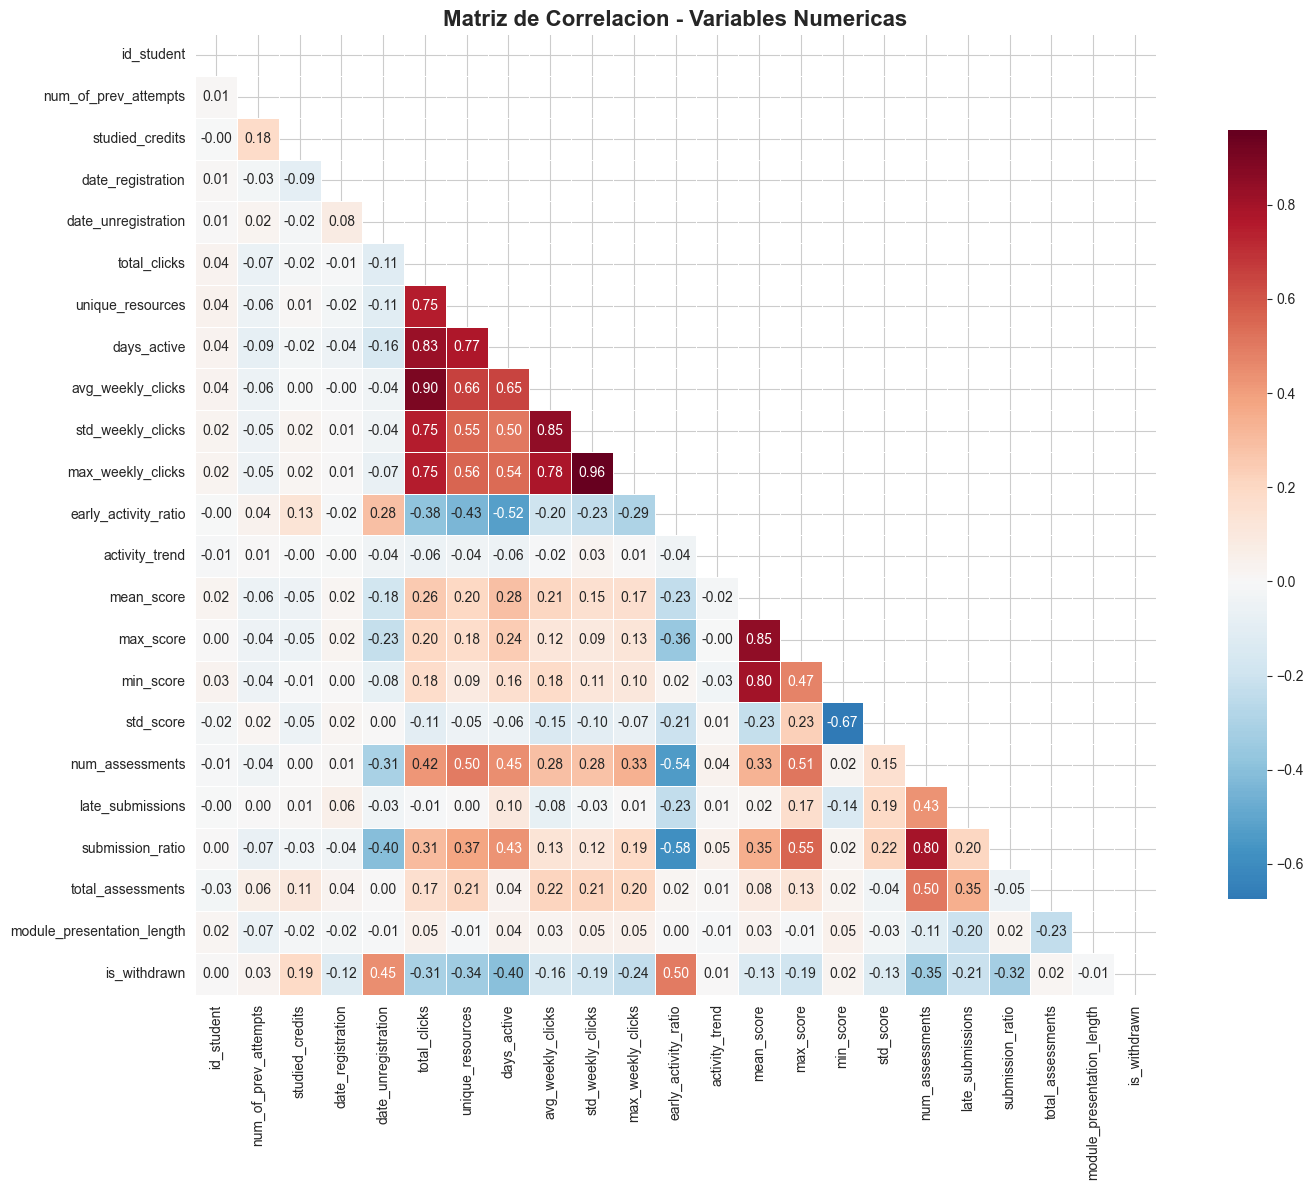


Correlaciones con is_withdrawn (abandono):
  Variables con correlacion positiva (mayor abandono):
    studied_credits                    : +0.191
    date_unregistration                : +0.445
    early_activity_ratio               : +0.497

  Variables con correlacion negativa (menor abandono):
    days_active                        : -0.396
    num_assessments                    : -0.347
    unique_resources                   : -0.337
    submission_ratio                   : -0.319
    total_clicks                       : -0.309
    max_weekly_clicks                  : -0.235
    late_submissions                   : -0.210
    max_score                          : -0.191
    std_weekly_clicks                  : -0.185
    avg_weekly_clicks                  : -0.164
    mean_score                         : -0.134
    std_score                          : -0.131
    date_registration                  : -0.122

--- Hallazgos de correlacion ---
• 'mean_score' tiene la correlacion negativ

In [123]:
# EDA 4: Matriz de correlacion

# Seleccionar solo columnas numericas para correlacion
numeric_for_corr = master.select_dtypes(include=['int64', 'float64']).copy()

# Incluir is_withdrawn como referencia
if 'is_withdrawn' not in numeric_for_corr.columns:
    numeric_for_corr['is_withdrawn'] = master['is_withdrawn']

# Calcular matriz de correlacion
corr_matrix = numeric_for_corr.corr()

# Heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlacion - Variables Numericas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
target_corr = corr_matrix['is_withdrawn'].drop('is_withdrawn').sort_values()

print("\nCorrelaciones con is_withdrawn (abandono):")
print("  Variables con correlacion positiva (mayor abandono):")
for var, corr in target_corr[target_corr > 0.05].items():
    print(f"    {var:35s}: {corr:+.3f}")
print("\n  Variables con correlacion negativa (menor abandono):")
for var, corr in target_corr[target_corr < -0.05].items():
    print(f"    {var:35s}: {corr:+.3f}")

print("\n--- Hallazgos de correlacion ---")
print("• 'mean_score' tiene la correlacion negativa mas fuerte con abandono.")
print("• 'submission_ratio' y 'total_clicks' tambien correlacionan negativamente.")
print("• Las variables demograficas tienen correlacion debil pero consistente.")

Analisis temporal de actividad...


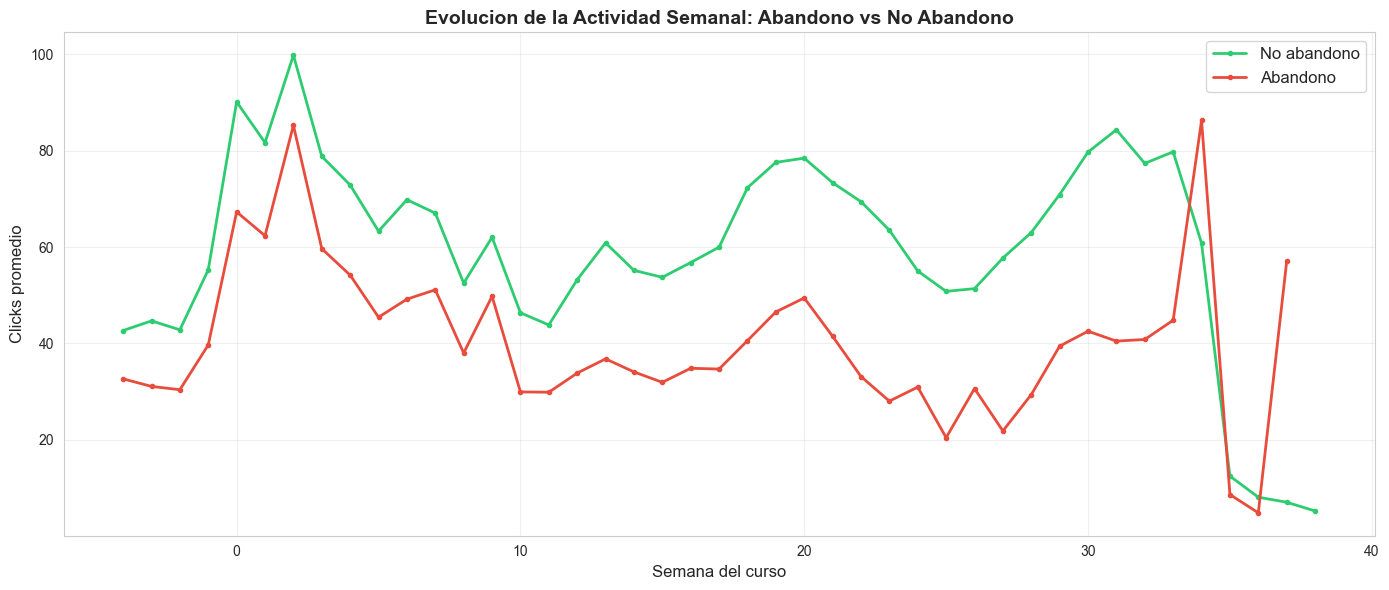


--- Hallazgos temporales ---
• Los estudiantes que abandonan muestran menos actividad desde el inicio.
• La brecha de actividad se acentua a partir de la semana 10.
• Los estudiantes que no abandonan mantienen actividad constante o creciente.


In [124]:
# EDA 5: Evolucion temporal de la actividad

print("Analisis temporal de actividad...")

# Usar los datos semanales ya calculados
# Merge con informacion de abandono
weekly_with_target = weekly_clicks.merge(
    master[['id_student', 'code_module', 'code_presentation', 'is_withdrawn']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
)

# Promedio de clicks por semana, separado por grupo
weekly_avg = weekly_with_target.groupby(['week', 'is_withdrawn'])['sum_click'].mean().reset_index()

# Grafico de lineas
plt.figure(figsize=(14, 6))
for group, color, label in [(0, '#2ecc71', 'No abandono'), (1, '#e74c3c', 'Abandono')]:
    data = weekly_avg[weekly_avg['is_withdrawn'] == group]
    plt.plot(data['week'], data['sum_click'], color=color, linewidth=2,
             label=label, marker='o', markersize=3)

plt.xlabel('Semana del curso', fontsize=12)
plt.ylabel('Clicks promedio', fontsize=12)
plt.title('Evolucion de la Actividad Semanal: Abandono vs No Abandono', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Hallazgos temporales ---")
print("• Los estudiantes que abandonan muestran menos actividad desde el inicio.")
print("• La brecha de actividad se acentua a partir de la semana 10.")
print("• Los estudiantes que no abandonan mantienen actividad constante o creciente.")

---
## SECCION 7: Modelos Supervisados y Validacion Temporal

Entrenamos tres modelos defendibles para el problema:

- **Logistic Regression** como baseline interpretable.
- **Random Forest** como modelo robusto no lineal.
- **XGBoost** como boosting de alto rendimiento.

La validacion principal usa una separacion temporal realista: entrenar con presentaciones 2013 y testear con presentaciones 2014.

In [125]:
# CONFIGURACION DE MODELOS SUPERVISADOS

model_specs = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("Modelos definidos:")
for name in model_specs:
    print(f"- {name}")

Modelos definidos:
- Logistic Regression
- Random Forest
- XGBoost


In [126]:
# ENTRENAMIENTO POR SNAPSHOT CON SPLIT TEMPORAL 2013 -> 2014

all_results = []
model_outputs = {}
models_dict = {}
predictions = {}

for week, df_week in temporal_datasets.items():
    train_df = df_week[df_week['presentation_year'] == 2013].copy()
    test_df = df_week[df_week['presentation_year'] == 2014].copy()

    X_train_raw, y_train = split_features_target(train_df)
    X_test_raw, y_test = split_features_target(test_df)

    print(f"\n{'='*70}")
    print(f"SNAPSHOT SEMANA {week}: train 2013={len(train_df)} | test 2014={len(test_df)}")
    print(f"Abandono train={y_train.mean()*100:.1f}% | test={y_test.mean()*100:.1f}%")
    print(f"{'='*70}")

    for model_name, estimator in model_specs.items():
        pipeline = Pipeline(steps=[
            ('preprocess', build_preprocessor(X_train_raw)),
            ('model', estimator)
        ])

        pipeline.fit(X_train_raw, y_train)
        y_pred = pipeline.predict(X_test_raw)
        y_proba = pipeline.predict_proba(X_test_raw)[:, 1]
        metrics = evaluate_predictions(y_test, y_pred, y_proba)

        row = {'Semana': week, 'Modelo': model_name, **metrics}
        all_results.append(row)
        model_key = f"Semana {week} - {model_name}"
        model_outputs[model_key] = {
            'pipeline': pipeline,
            'X_train': X_train_raw,
            'X_test': X_test_raw,
            'y_train': y_train,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_proba': y_proba
        }
        models_dict[model_key] = pipeline
        predictions[model_key] = (y_pred, y_proba)

        print(f"{model_name:20s} | Recall={metrics['Recall']:.3f} | F1={metrics['F1-Score']:.3f} | ROC-AUC={metrics['ROC-AUC']:.3f}")

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(['Semana', 'F1-Score', 'Recall'], ascending=[True, False, False])

display(results_df.style.format({
    'Accuracy': '{:.3f}', 'Precision': '{:.3f}', 'Recall': '{:.3f}',
    'F1-Score': '{:.3f}', 'ROC-AUC': '{:.3f}'
}))


SNAPSHOT SEMANA 2: train 2013=13529 | test 2014=19064
Abandono train=27.5% | test=33.8%
Logistic Regression  | Recall=0.606 | F1=0.604 | ROC-AUC=0.761
Random Forest        | Recall=0.436 | F1=0.554 | ROC-AUC=0.774
XGBoost              | Recall=0.389 | F1=0.531 | ROC-AUC=0.774

SNAPSHOT SEMANA 4: train 2013=13529 | test 2014=19064
Abandono train=27.5% | test=33.8%
Logistic Regression  | Recall=0.645 | F1=0.652 | ROC-AUC=0.801
Random Forest        | Recall=0.588 | F1=0.655 | ROC-AUC=0.820
XGBoost              | Recall=0.517 | F1=0.638 | ROC-AUC=0.826

SNAPSHOT SEMANA 6: train 2013=13529 | test 2014=19064
Abandono train=27.5% | test=33.8%
Logistic Regression  | Recall=0.656 | F1=0.675 | ROC-AUC=0.830
Random Forest        | Recall=0.600 | F1=0.671 | ROC-AUC=0.843
XGBoost              | Recall=0.541 | F1=0.660 | ROC-AUC=0.845


,Semana,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,2,Logistic Regression,0.732,0.603,0.606,0.604,0.761
1,2,Random Forest,0.763,0.761,0.436,0.554,0.774
2,2,XGBoost,0.768,0.837,0.389,0.531,0.774
4,4,Random Forest,0.791,0.740,0.588,0.655,0.820
3,4,Logistic Regression,0.767,0.659,0.645,0.652,0.801
5,4,XGBoost,0.801,0.831,0.517,0.638,0.826
6,6,Logistic Regression,0.787,0.697,0.656,0.675,0.830
7,6,Random Forest,0.801,0.760,0.600,0.671,0.843
8,6,XGBoost,0.812,0.846,0.541,0.660,0.845


,Semana,Modelo,Recall,F1-Score,ROC-AUC,Precision,Accuracy
0,2,Logistic Regression,0.606,0.604,0.761,0.603,0.732
1,4,Random Forest,0.588,0.655,0.820,0.740,0.791
2,6,Logistic Regression,0.656,0.675,0.830,0.697,0.787


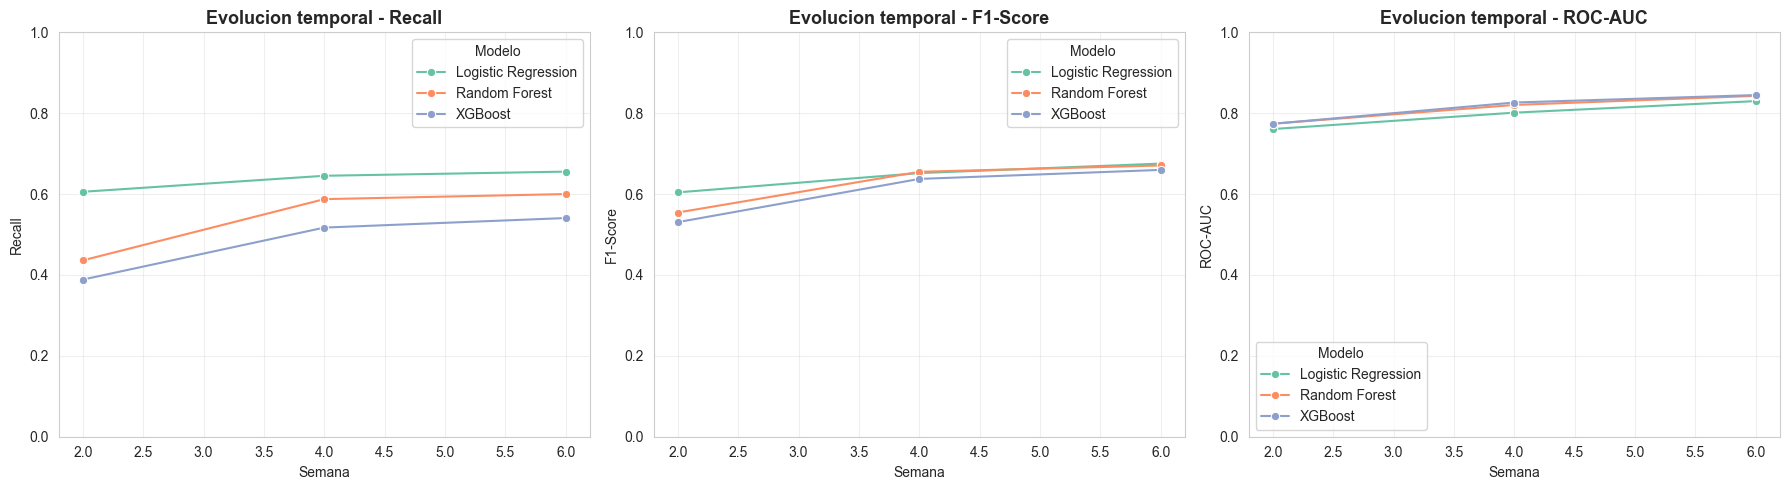

Interpretacion clave:
El sistema se evalua como alerta temprana: interesa especialmente el Recall, porque un falso negativo significa no detectar a un estudiante en riesgo.
La comparacion por semanas permite ver cuanto mejora la deteccion al acumular mas evidencia temporal.


In [127]:
# TABLA CLAVE: MEJOR MODELO POR SEMANA

best_by_week = (
    results_df.sort_values(['Semana', 'F1-Score', 'Recall', 'ROC-AUC'], ascending=[True, False, False, False])
    .groupby('Semana')
    .head(1)
    .reset_index(drop=True)
)

display(best_by_week[['Semana', 'Modelo', 'Recall', 'F1-Score', 'ROC-AUC', 'Precision', 'Accuracy']].style.format({
    'Recall': '{:.3f}', 'F1-Score': '{:.3f}', 'ROC-AUC': '{:.3f}',
    'Precision': '{:.3f}', 'Accuracy': '{:.3f}'
}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['Recall', 'F1-Score', 'ROC-AUC']
for ax, metric in zip(axes, metrics_to_plot):
    sns.lineplot(data=results_df, x='Semana', y=metric, hue='Modelo', marker='o', ax=ax)
    ax.set_title(f'Evolucion temporal - {metric}', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretacion clave:")
print("El sistema se evalua como alerta temprana: interesa especialmente el Recall, porque un falso negativo significa no detectar a un estudiante en riesgo.")
print("La comparacion por semanas permite ver cuanto mejora la deteccion al acumular mas evidencia temporal.")

,Metodo,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random split,Logistic Regression,0.807,0.693,0.683,0.688,0.849
3,Temporal split,Logistic Regression,0.787,0.697,0.656,0.675,0.830
1,Random split,Random Forest,0.822,0.771,0.610,0.681,0.855
4,Temporal split,Random Forest,0.801,0.760,0.600,0.671,0.843
2,Random split,XGBoost,0.826,0.804,0.583,0.676,0.860
5,Temporal split,XGBoost,0.812,0.846,0.541,0.660,0.845


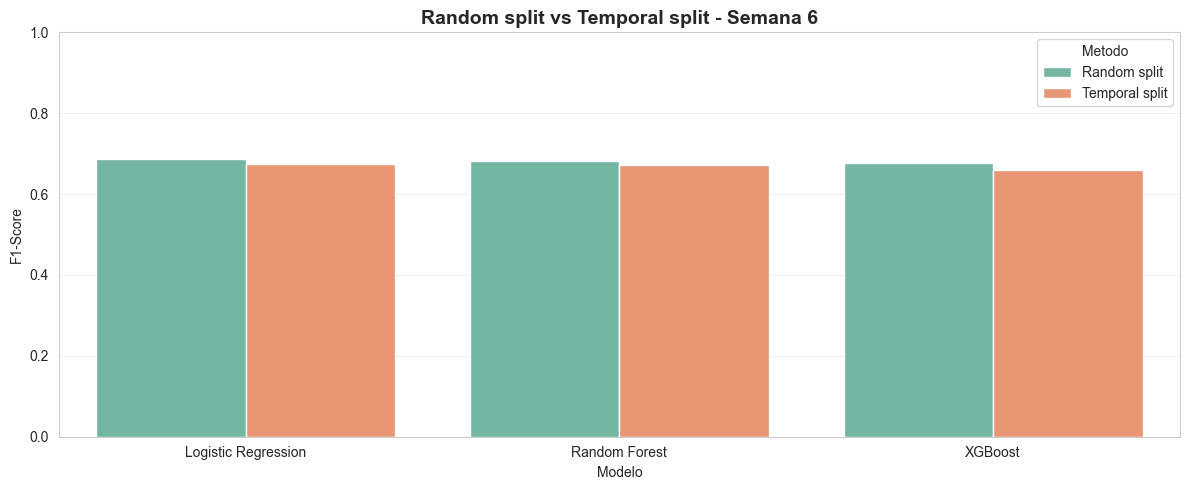

Conclusion metodologica:
El split temporal es mas exigente y representa mejor el uso real: entrenar con cohortes pasadas y predecir cohortes futuras.


In [128]:
# COMPARACION RANDOM SPLIT VS TEMPORAL SPLIT EN SEMANA 6

week = 6
random_df = temporal_datasets[week].copy()
X_random_raw, y_random = split_features_target(random_df)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_random_raw, y_random, test_size=0.2, stratify=y_random, random_state=RANDOM_STATE
)

random_split_rows = []
for model_name, estimator in model_specs.items():
    pipeline = Pipeline(steps=[
        ('preprocess', build_preprocessor(X_train_r)),
        ('model', estimator)
    ])
    pipeline.fit(X_train_r, y_train_r)
    y_pred_r = pipeline.predict(X_test_r)
    y_proba_r = pipeline.predict_proba(X_test_r)[:, 1]
    metrics_r = evaluate_predictions(y_test_r, y_pred_r, y_proba_r)
    random_split_rows.append({'Metodo': 'Random split', 'Modelo': model_name, **metrics_r})

week6_temporal = results_df[results_df['Semana'] == week].copy()
week6_temporal = week6_temporal.assign(Metodo='Temporal split')[['Metodo', 'Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
validation_comparison = pd.concat([pd.DataFrame(random_split_rows), week6_temporal], ignore_index=True)

display(validation_comparison.sort_values(['Modelo', 'Metodo']).style.format({
    'Accuracy': '{:.3f}', 'Precision': '{:.3f}', 'Recall': '{:.3f}',
    'F1-Score': '{:.3f}', 'ROC-AUC': '{:.3f}'
}))

plt.figure(figsize=(12, 5))
sns.barplot(data=validation_comparison, x='Modelo', y='F1-Score', hue='Metodo')
plt.title('Random split vs Temporal split - Semana 6', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Conclusion metodologica:")
print("El split temporal es mas exigente y representa mejor el uso real: entrenar con cohortes pasadas y predecir cohortes futuras.")

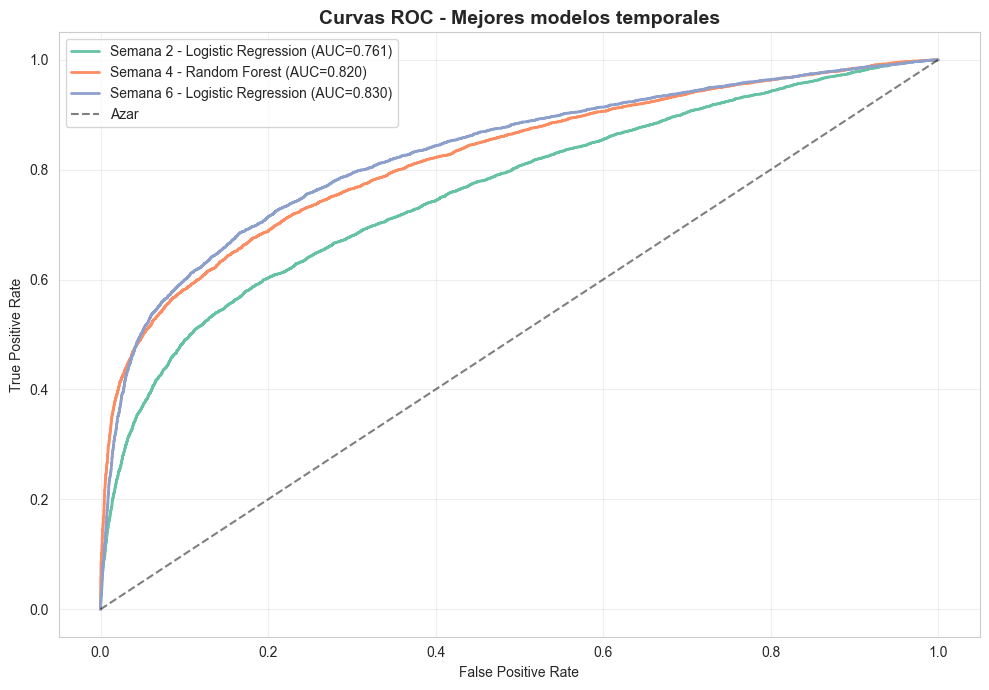

In [129]:
# CURVAS ROC DEL MEJOR MODELO DE CADA SEMANA

plt.figure(figsize=(10, 7))
for _, row in best_by_week.iterrows():
    key = f"Semana {int(row['Semana'])} - {row['Modelo']}"
    output = model_outputs[key]
    fpr, tpr, _ = roc_curve(output['y_test'], output['y_proba'])
    plt.plot(fpr, tpr, linewidth=2, label=f"Semana {int(row['Semana'])} - {row['Modelo']} (AUC={row['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC - Mejores modelos temporales', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

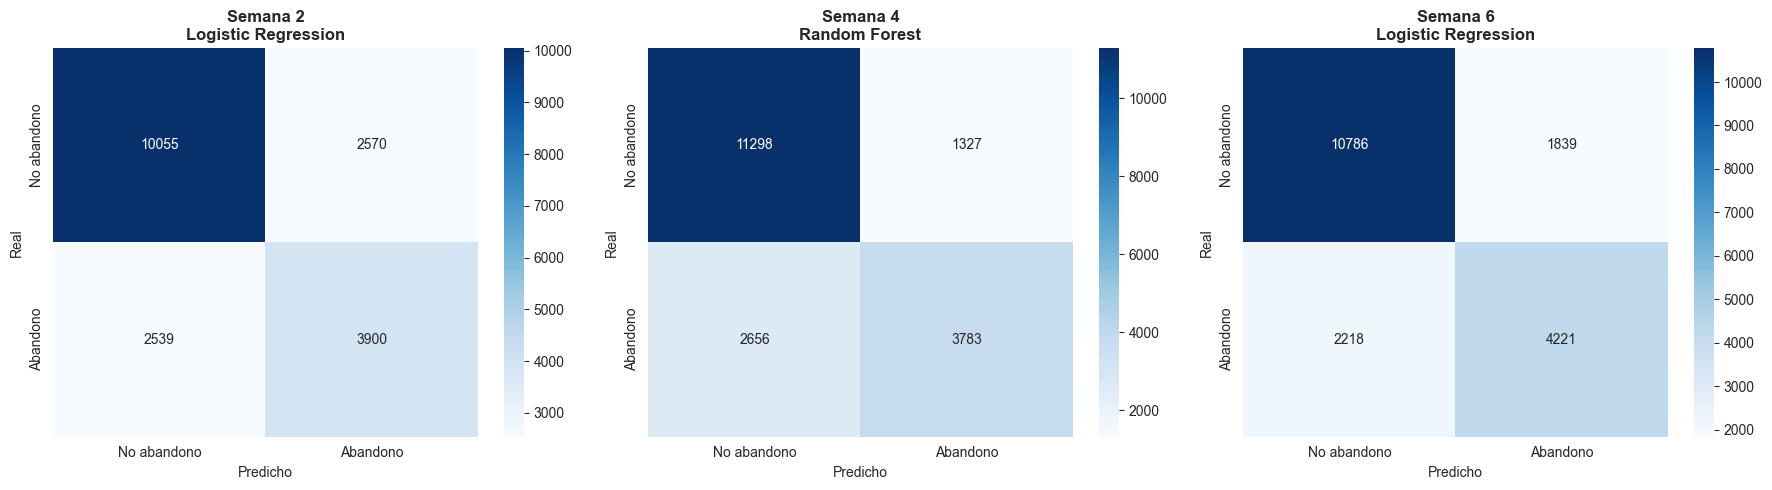

In [130]:
# MATRICES DE CONFUSION DEL MEJOR MODELO DE CADA SEMANA

fig, axes = plt.subplots(1, len(best_by_week), figsize=(6 * len(best_by_week), 5))
if len(best_by_week) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, best_by_week.iterrows()):
    key = f"Semana {int(row['Semana'])} - {row['Modelo']}"
    output = model_outputs[key]
    cm = confusion_matrix(output['y_test'], output['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No abandono', 'Abandono'],
                yticklabels=['No abandono', 'Abandono'])
    ax.set_title(f"Semana {int(row['Semana'])}\n{row['Modelo']}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

In [131]:
# SELECCION DEL MODELO PARA INTERPRETABILIDAD

# Priorizamos semana 6 porque ofrece mas evidencia temprana sin llegar al final del curso.
# Dentro de esa semana seleccionamos por F1 y usamos Recall como desempate.
week_for_interpretability = 6
candidate_rows = results_df[results_df['Semana'] == week_for_interpretability].sort_values(
    ['F1-Score', 'Recall', 'ROC-AUC'], ascending=False
)
best_row = candidate_rows.iloc[0]
best_model_name = f"Semana {int(best_row['Semana'])} - {best_row['Modelo']}"
best_model = model_outputs[best_model_name]['pipeline']

print("Modelo seleccionado para SHAP:")
print(f"{best_model_name}")
print(f"Recall={best_row['Recall']:.3f} | F1={best_row['F1-Score']:.3f} | ROC-AUC={best_row['ROC-AUC']:.3f}")

print("\nLectura critica:")
print("- Logistic Regression aporta interpretabilidad y baseline.")
print("- Random Forest captura no linealidades con buena robustez.")
print("- XGBoost suele mejorar performance, pero se justifica solo si compensa su menor simplicidad.")

Modelo seleccionado para SHAP:
Semana 6 - Logistic Regression
Recall=0.656 | F1=0.675 | ROC-AUC=0.830

Lectura critica:
- Logistic Regression aporta interpretabilidad y baseline.
- Random Forest captura no linealidades con buena robustez.
- XGBoost suele mejorar performance, pero se justifica solo si compensa su menor simplicidad.


---
## SECCIÓN 5: Reducción Dimensional — PCA

### ¿Por qué PCA?

El Análisis de Componentes Principales (PCA) nos permite:
1. **Reducir dimensionalidad**: simplificar el dataset manteniendo la mayor varianza posible
2. **Visualizar patrones**: proyectar los datos en 2D o 3D para identificar clusters o tendencias
3. **Eliminar redundancia**: cuando hay features correlacionadas, PCA las combina en componentes independientes

Esto es útil tanto para visualización (entender la estructura de los datos) como para mejorar el rendimiento de algunos modelos (KNN, Logistic Regression) al eliminar ruido.

Aplicando PCA al dataset...
Varianza explicada por los primeros componentes:
  PC1: 0.3144 (0.3144 acumulado)
  PC2: 0.0943 (0.4087 acumulado)
  PC3: 0.0655 (0.4742 acumulado)
  PC4: 0.0532 (0.5273 acumulado)
  PC5: 0.0513 (0.5786 acumulado)
  PC6: 0.0464 (0.6250 acumulado)
  PC7: 0.0396 (0.6646 acumulado)
  PC8: 0.0358 (0.7004 acumulado)
  PC9: 0.0319 (0.7323 acumulado)
  PC10: 0.0288 (0.7611 acumulado)


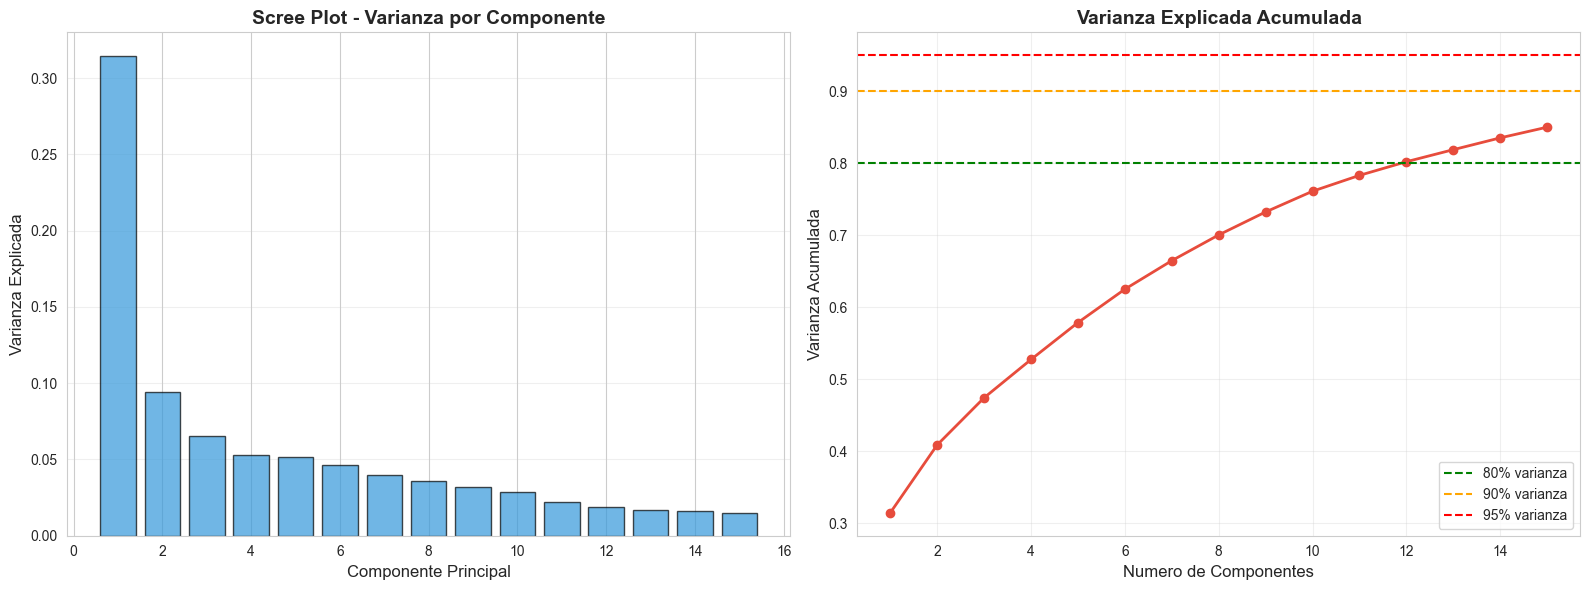


Componentes necesarios para:
  90% de varianza: 21 componentes
  95% de varianza: 32 componentes


In [132]:
# APLICACION DE PCA

print("Aplicando PCA al dataset...")

# Aplicar PCA sobre X_final completo (ya escalado)
pca = PCA()
X_pca = pca.fit_transform(X_final)

# Varianza explicada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Varianza explicada por los primeros componentes:")
for i in range(min(10, len(explained_variance))):
    print(f"  PC{i+1}: {explained_variance[i]:.4f} ({cumulative_variance[i]:.4f} acumulado)")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Varianza individual
ax = axes[0]
ax.bar(range(1, len(explained_variance[:15]) + 1), explained_variance[:15],
       color='#3498db', edgecolor='black', alpha=0.7)
ax.set_xlabel('Componente Principal', fontsize=12)
ax.set_ylabel('Varianza Explicada', fontsize=12)
ax.set_title('Scree Plot - Varianza por Componente', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Grafico 2: Varianza acumulada
ax = axes[1]
ax.plot(range(1, len(cumulative_variance[:15]) + 1), cumulative_variance[:15],
        marker='o', linewidth=2, color='#e74c3c')
ax.axhline(y=0.8, color='green', linestyle='--', label='80% varianza')
ax.axhline(y=0.9, color='orange', linestyle='--', label='90% varianza')
ax.axhline(y=0.95, color='red', linestyle='--', label='95% varianza')
ax.set_xlabel('Numero de Componentes', fontsize=12)
ax.set_ylabel('Varianza Acumulada', fontsize=12)
ax.set_title('Varianza Explicada Acumulada', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determinar numero de componentes para retener 90% de varianza
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nComponentes necesarios para:")
print(f"  90% de varianza: {n_components_90} componentes")
print(f"  95% de varianza: {n_components_95} componentes")

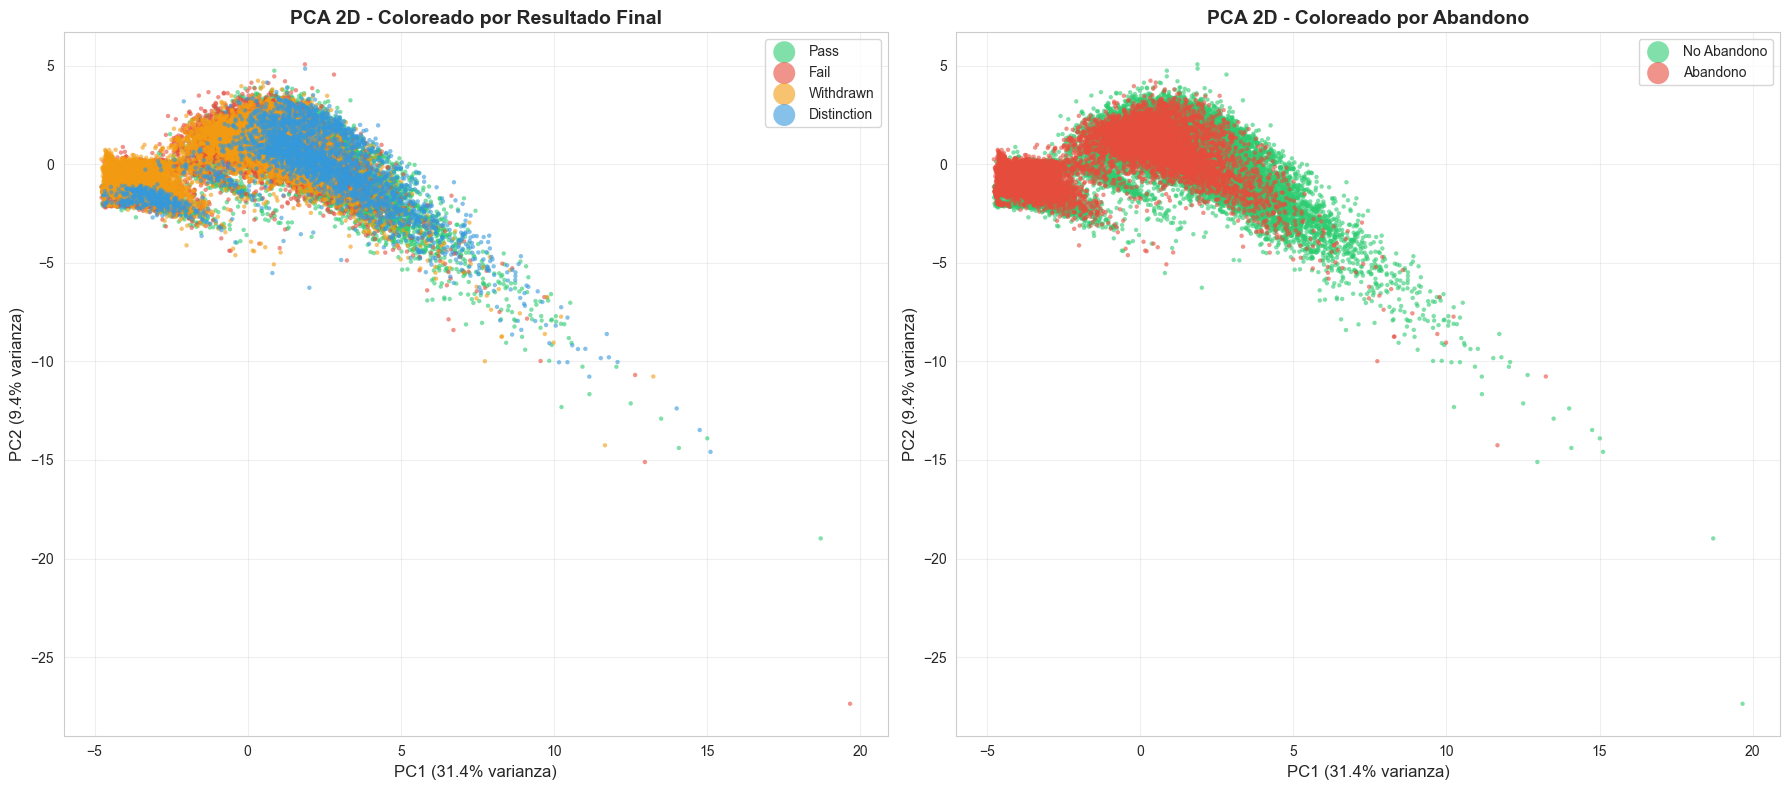


Interpretacion:
• En el espacio PCA, los estudiantes que abandonan (Withdrawn) tienden a
  agruparse en ciertas regiones, sugiriendo patrones de comportamiento comunes.
• Los estudiantes con Distinction y Pass se superponen considerablemente.


In [133]:
# VISUALIZACION PCA 2D

# Reducir a 2 componentes para visualizacion
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_final)

# Crear DataFrame para graficar
pca_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'final_result': master['final_result'].values,
    'is_withdrawn': master['is_withdrawn'].values
})

# Grafico 1: Coloreado por resultado final
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
colors_map = {'Pass': '#2ecc71', 'Fail': '#e74c3c', 'Withdrawn': '#f39c12', 'Distinction': '#3498db'}
for result, color in colors_map.items():
    subset = pca_df[pca_df['final_result'] == result]
    if len(subset) > 0:
        ax.scatter(subset['PC1'], subset['PC2'], c=color, label=result,
                   alpha=0.6, s=10, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title('PCA 2D - Coloreado por Resultado Final', fontsize=14, fontweight='bold')
ax.legend(markerscale=5)
ax.grid(True, alpha=0.3)

# Grafico 2: Coloreado por abandono (binario)
ax = axes[1]
colors_target = {0: '#2ecc71', 1: '#e74c3c'}
for target_val, color in colors_target.items():
    subset = pca_df[pca_df['is_withdrawn'] == target_val]
    label = 'No Abandono' if target_val == 0 else 'Abandono'
    ax.scatter(subset['PC1'], subset['PC2'], c=color, label=label,
               alpha=0.6, s=10, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title('PCA 2D - Coloreado por Abandono', fontsize=14, fontweight='bold')
ax.legend(markerscale=5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretacion:")
print("• En el espacio PCA, los estudiantes que abandonan (Withdrawn) tienden a")
print("  agruparse en ciertas regiones, sugiriendo patrones de comportamiento comunes.")
print("• Los estudiantes con Distinction y Pass se superponen considerablemente.")

In [134]:
# ANALISIS DE PCA LOADINGS

# Mostrar las features que mas pesan en los primeros componentes
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=X_final.columns
)

print("Top 10 features con mayor peso en PC1:")
pc1_top = loadings['PC1'].abs().sort_values(ascending=False).head(10)
for feature, weight in pc1_top.items():
    direction = 'positivo' if loadings.loc[feature, 'PC1'] > 0 else 'negativo'
    print(f"  {feature:35s}: {loadings.loc[feature, 'PC1']:.4f} ({direction})")

print("\nTop 10 features con mayor peso en PC2:")
pc2_top = loadings['PC2'].abs().sort_values(ascending=False).head(10)
for feature, weight in pc2_top.items():
    direction = 'positivo' if loadings.loc[feature, 'PC2'] > 0 else 'negativo'
    print(f"  {feature:35s}: {loadings.loc[feature, 'PC2']:.4f} ({direction})")

print("\nInterpretacion:")
print("• PC1 captura principalmente el nivel de engagement (clicks, actividad)")
print("• PC2 captura aspectos academicos (notas, entregas)")

Top 10 features con mayor peso en PC1:
  max_score_until_week               : 0.3020 (positivo)
  active_days_until_week             : 0.3006 (positivo)
  mean_score_until_week              : 0.2998 (positivo)
  active_weeks_until_week            : 0.2989 (positivo)
  min_score_until_week               : 0.2934 (positivo)
  submission_ratio_until_week        : 0.2888 (positivo)
  unique_resources_until_week        : 0.2760 (positivo)
  last_activity_day                  : 0.2744 (positivo)
  clicks_until_week                  : 0.2710 (positivo)
  avg_clicks_per_active_week         : 0.2634 (positivo)

Top 10 features con mayor peso en PC2:
  assessments_due_until_week         : 0.3381 (positivo)
  clicks_until_week                  : -0.3310 (negativo)
  avg_clicks_per_active_week         : -0.3271 (negativo)
  clicks_previous_7_days             : -0.3260 (negativo)
  clicks_last_7_days                 : -0.2872 (negativo)
  late_submissions_until_week        : 0.2838 (positivo)
  max

---
## SECCIÓN 6: Aprendizaje No Supervisado — Clustering K-Means

### ¿Por qué K-Means?

El clustering no supervisado nos permite descubrir **perfiles naturales de estudiantes** sin usar etiquetas previas. K-Means es el algoritmo de clustering más utilizado porque:
- Es simple e interpretable
- Escala bien a datasets medianos/grandes
- Produce clusters compactos y bien separados

### ¿Qué esperamos encontrar?

Perfiles como:
- **Alto rendimiento**: muchos clicks, buenas notas, actividad constante
- **Bajo engagement**: poca actividad en plataforma, riesgo de abandono
- **Estudiantes constantes**: actividad regular, rendimiento medio
- **Riesgo académico**: entregan poco, notas bajas

Usaremos las features normalizadas y también probaremos clustering sobre los datos reducidos por PCA para comparar.

Determinando el numero optimo de clusters K...
  K=2: Inercia=646962.57, Silhouette=0.2380
  K=3: Inercia=575714.33, Silhouette=0.2015
  K=4: Inercia=544089.85, Silhouette=0.1518
  K=5: Inercia=521273.32, Silhouette=0.1175
  K=6: Inercia=500709.51, Silhouette=0.1119
  K=7: Inercia=482940.91, Silhouette=0.1089
  K=8: Inercia=468953.12, Silhouette=0.1047
  K=9: Inercia=456857.76, Silhouette=0.1069
  K=10: Inercia=448592.98, Silhouette=0.1055


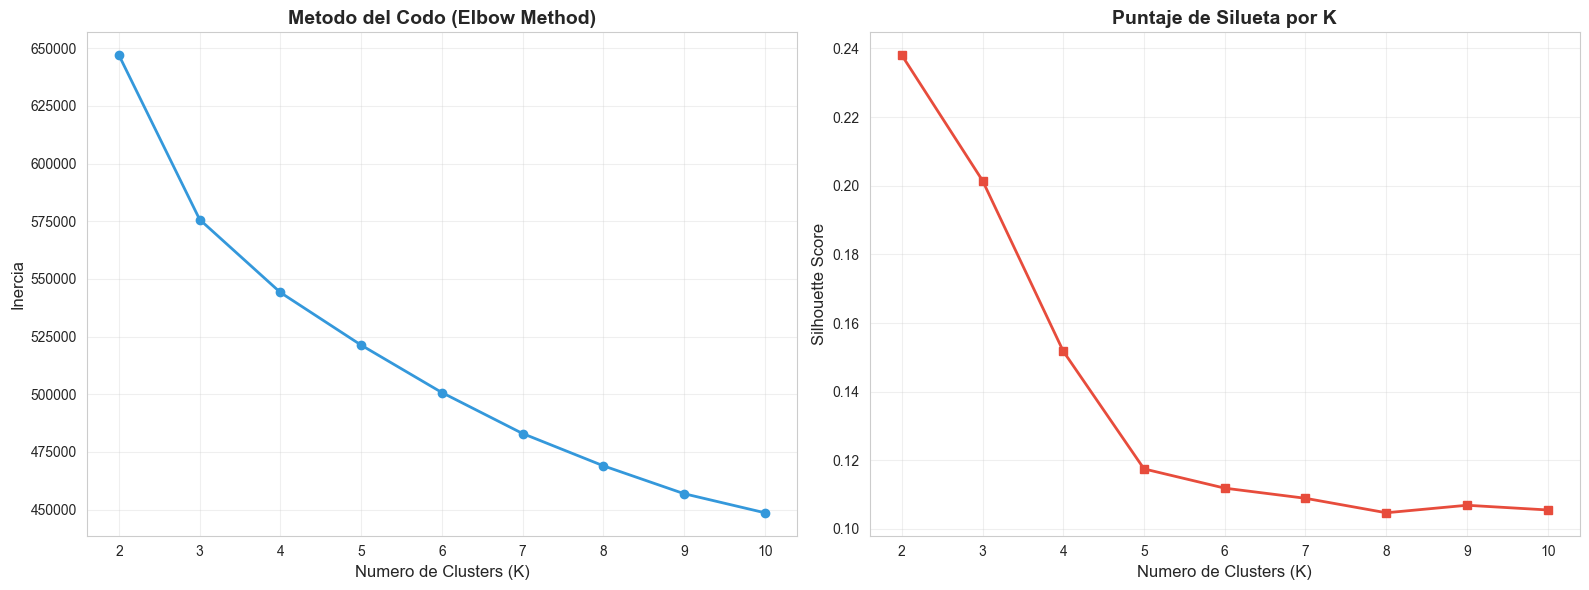


K optimo (segun Silhouette): 2 (Silhouette = 0.2380)

Interpretacion:
• El silhouette score mide que tan compactos y separados estan los clusters.
• Valores > 0.5 indican estructura de clustering razonable.
• Elegimos K=2 para el analisis de perfiles.


In [135]:
# DETERMINACION DEL NUMERO OPTIMO DE CLUSTERS (K)

print("Determinando el numero optimo de clusters K...")

# Probar diferentes valores de K
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_final)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_final, labels))
    print(f"  K={k}: Inercia={kmeans.inertia_:.2f}, Silhouette={silhouettes[-1]:.4f}")

# Elbow method y Silhouette plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Elbow Method
ax = axes[0]
ax.plot(list(k_range), inertias, marker='o', linewidth=2, color='#3498db')
ax.set_xlabel('Numero de Clusters (K)', fontsize=12)
ax.set_ylabel('Inercia', fontsize=12)
ax.set_title('Metodo del Codo (Elbow Method)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Grafico 2: Silhouette Score
ax = axes[1]
ax.plot(list(k_range), silhouettes, marker='s', linewidth=2, color='#e74c3c')
ax.set_xlabel('Numero de Clusters (K)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Puntaje de Silueta por K', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Elegir K optimo
best_k = k_range[np.argmax(silhouettes)]
print(f"\nK optimo (segun Silhouette): {best_k} (Silhouette = {max(silhouettes):.4f})")
print("\nInterpretacion:")
print("• El silhouette score mide que tan compactos y separados estan los clusters.")
print(f"• Valores > 0.5 indican estructura de clustering razonable.")
print(f"• Elegimos K={best_k} para el analisis de perfiles.")

Entrenando K-Means con K=2...
✓ Clustering completado.

Distribucion de estudiantes por cluster:
  Cluster 0: 10098 estudiantes (31.0%)
  Cluster 1: 22495 estudiantes (69.0%)


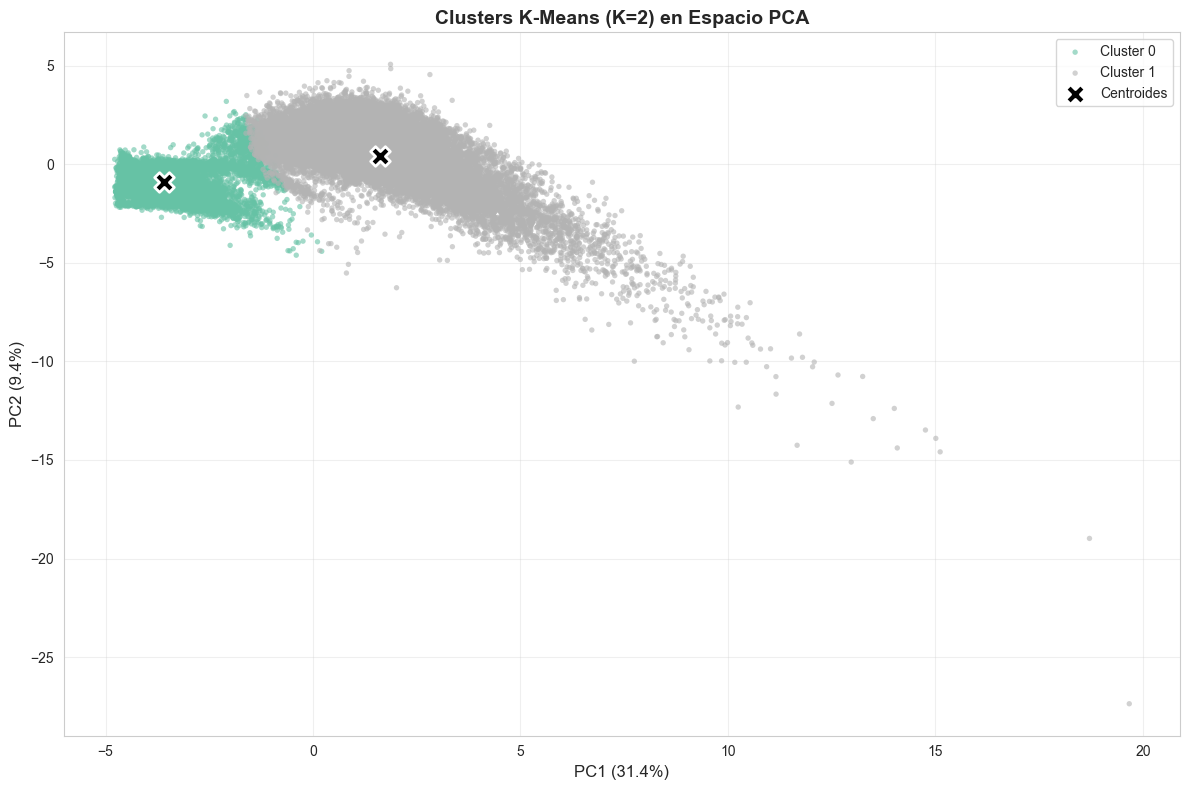

In [136]:
# ENTRENAMIENTO DE K-MEANS CON K OPTIMO

print(f"Entrenando K-Means con K={best_k}...")

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_final)

# Agregar etiquetas al dataset original para analisis
master['cluster'] = cluster_labels

print(f"✓ Clustering completado.")
print(f"\nDistribucion de estudiantes por cluster:")
cluster_counts = master['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(master) * 100
    print(f"  Cluster {cluster_id}: {count} estudiantes ({pct:.1f}%)")

# Visualizar clusters en espacio PCA 2D
pca_df['cluster'] = cluster_labels

plt.figure(figsize=(12, 8))
colors = plt.cm.Set2(np.linspace(0, 1, best_k))
for cluster_id in range(best_k):
    subset = pca_df[pca_df['cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'], c=[colors[cluster_id]],
                label=f'Cluster {cluster_id}', alpha=0.6, s=15, edgecolors='none')

# Centroides de clusters en espacio PCA
cluster_centers_pca = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(cluster_centers_pca[:, 0], cluster_centers_pca[:, 1],
            c='black', marker='X', s=200, edgecolors='white', linewidth=2,
            label='Centroides')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title(f'Clusters K-Means (K={best_k}) en Espacio PCA', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Analizando perfiles de cada cluster...

Perfiles promedio por cluster:


,total_clicks,avg_weekly_clicks,mean_score,submission_ratio,early_activity_ratio,activity_trend,num_of_prev_attempts,studied_credits
cluster,,,,,,,,
0,457.48,30.56,72.21,0.76,0.63,0.41,0.17,78.18
1,1665.88,58.62,73.99,0.69,0.53,-0.75,0.16,80.47



Tasa de abandono por cluster:


,Tasa Abandono,Total Estudiantes
cluster,,
0,59.8,10098
1,18.3,22495


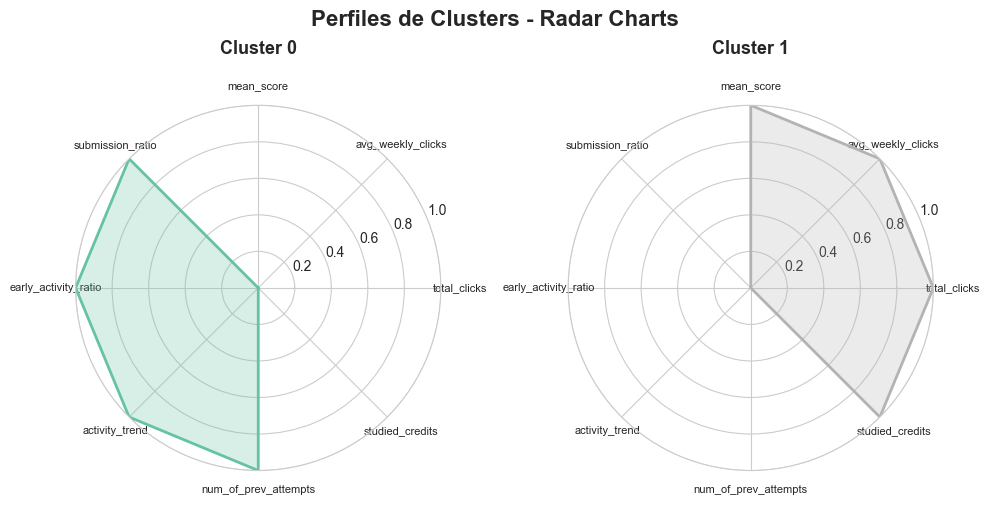

In [137]:
# ANALISIS DE PERFILES DE CLUSTERS

print("Analizando perfiles de cada cluster...\n")

# Seleccionar variables para describir los clusters
profile_vars = ['total_clicks', 'avg_weekly_clicks', 'mean_score', 'submission_ratio',
                'early_activity_ratio', 'activity_trend', 'num_of_prev_attempts',
                'studied_credits']

# Calcular promedio de cada variable por cluster
cluster_profiles = master.groupby('cluster')[profile_vars].mean().round(2)

print("Perfiles promedio por cluster:")
display(cluster_profiles)

# Tasa de abandono por cluster
print("\nTasa de abandono por cluster:")
withdrawal_by_cluster = master.groupby('cluster')['is_withdrawn'].agg(['mean', 'count']).round(3)
withdrawal_by_cluster.columns = ['Tasa Abandono', 'Total Estudiantes']
withdrawal_by_cluster['Tasa Abandono'] = withdrawal_by_cluster['Tasa Abandono'] * 100
display(withdrawal_by_cluster)

# Radar charts por cluster
fig, axes = plt.subplots(1, best_k, figsize=(5*best_k, 5), subplot_kw=dict(polar=True))
if best_k == 1:
    axes = [axes]

# Normalizar los datos para el radar chart
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
cluster_profiles_normalized = pd.DataFrame(
    scaler_radar.fit_transform(cluster_profiles),
    columns=cluster_profiles.columns,
    index=cluster_profiles.index
)

angles = np.linspace(0, 2 * np.pi, len(profile_vars), endpoint=False).tolist()
angles += angles[:1]

for i, cluster_id in enumerate(range(best_k)):
    ax = axes[i]
    values = cluster_profiles_normalized.loc[cluster_id].values.tolist()
    values += values[:1]
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(profile_vars, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster_id}', fontsize=13, fontweight='bold', pad=20)

plt.suptitle('Perfiles de Clusters - Radar Charts', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [138]:
# INTERPRETACION DE CLUSTERS

print("=" * 60)
print("INTERPRETACION DE PERFILES DE ESTUDIANTES")
print("=" * 60)

for cluster_id in range(best_k):
    subset = master[master['cluster'] == cluster_id]
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - {len(subset)} estudiantes ({len(subset)/len(master)*100:.1f}%)")
    print(f"{'='*50}")
    
    # Caracteristicas clave
    print(f"  Clicks totales (promedio): {subset['total_clicks'].mean():.0f}")
    print(f"  Nota promedio: {subset['mean_score'].mean():.1f}")
    print(f"  Ratio de entregas: {subset['submission_ratio'].mean():.2f}")
    print(f"  Actividad temprana: {subset['early_activity_ratio'].mean():.3f}")
    print(f"  Tasa de abandono: {subset['is_withdrawn'].mean()*100:.1f}%")
    
    # Perfil dominante
    withdrawal_rate = subset['is_withdrawn'].mean()
    mean_score = subset['mean_score'].mean()
    engagement = subset['total_clicks'].mean()
    
    if withdrawal_rate > 0.6:
        print(f"  >>> PERFIL: ALTO RIESGO DE ABANDONO")
    elif withdrawal_rate > 0.3:
        print(f"  >>> PERFIL: RIESGO MODERADO")
    elif mean_score > 70 and engagement > master['total_clicks'].median():
        print(f"  >>> PERFIL: ALTO RENDIMIENTO")
    elif mean_score > 50:
        print(f"  >>> PERFIL: RENDIMIENTO MODERADO")
    else:
        print(f"  >>> PERFIL: RIESGO ACADEMICO")

print("\n\nConclusion del clustering:")
print("• K-Means logro separar perfiles de estudiantes con distintos niveles de riesgo.")
print("• Los clusters de alto riesgo pueden ser objetivo de intervenciones tempranas.")
print("• Los perfiles identificados son consistentes con los hallazgos del EDA.")

INTERPRETACION DE PERFILES DE ESTUDIANTES

CLUSTER 0 - 10098 estudiantes (31.0%)
  Clicks totales (promedio): 457
  Nota promedio: 72.2
  Ratio de entregas: 0.76
  Actividad temprana: 0.631
  Tasa de abandono: 59.8%
  >>> PERFIL: RIESGO MODERADO

CLUSTER 1 - 22495 estudiantes (69.0%)
  Clicks totales (promedio): 1666
  Nota promedio: 74.0
  Ratio de entregas: 0.69
  Actividad temprana: 0.533
  Tasa de abandono: 18.3%
  >>> PERFIL: ALTO RENDIMIENTO


Conclusion del clustering:
• K-Means logro separar perfiles de estudiantes con distintos niveles de riesgo.
• Los clusters de alto riesgo pueden ser objetivo de intervenciones tempranas.
• Los perfiles identificados son consistentes con los hallazgos del EDA.


---
## SECCION 10: SHAP e Interpretabilidad

Usamos SHAP sobre el modelo temporal seleccionado para explicar que factores elevan o reducen el riesgo de abandono. La interpretacion se realiza sobre el conjunto de test 2014, manteniendo la logica de validacion temporal.

In [139]:
# PREPARACION DE SHAP PARA EL MEJOR MODELO TEMPORAL

best_output = model_outputs[best_model_name]
best_pipeline = best_output['pipeline']
preprocessor = best_pipeline.named_steps['preprocess']
estimator = best_pipeline.named_steps['model']

X_test_raw = best_output['X_test']
y_test = best_output['y_test']
y_pred_best = best_output['y_pred']
y_proba_best = best_output['y_proba']

sample_size = min(500, X_test_raw.shape[0])
X_test_sample_raw = X_test_raw.sample(sample_size, random_state=RANDOM_STATE)
sample_positions = X_test_raw.index.get_indexer(X_test_sample_raw.index)
y_test_sample = y_test.loc[X_test_sample_raw.index]
y_pred_sample = y_pred_best[sample_positions]


def align_transformed_matrix(matrix, names, estimator):
    """Alinea una matriz ya preprocesada con la cantidad de features que espera el modelo."""
    matrix = np.asarray(matrix)
    names = list(names)
    expected_features = getattr(estimator, 'n_features_in_', matrix.shape[1])
    current_features = matrix.shape[1]

    if current_features < expected_features:
        missing = expected_features - current_features
        print(f"Aviso: faltan {missing} columnas transformadas; se agregan columnas cero para alinear con el modelo.")
        matrix = np.hstack([matrix, np.zeros((matrix.shape[0], missing))])
        names = names + [f'missing_feature_{i+1}' for i in range(missing)]
    elif current_features > expected_features:
        extra = current_features - expected_features
        print(f"Aviso: sobran {extra} columnas transformadas; se recortan para alinear con el modelo.")
        matrix = matrix[:, :expected_features]
        names = names[:expected_features]

    return matrix, names


# Transformamos con el MISMO preprocessor ya ajustado dentro del pipeline ganador.
X_test_sample_transformed = preprocessor.transform(X_test_sample_raw)
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

X_test_sample_transformed, feature_names = align_transformed_matrix(
    X_test_sample_transformed,
    feature_names,
    estimator
)

X_test_sample = pd.DataFrame(
    X_test_sample_transformed,
    columns=feature_names,
    index=X_test_sample_raw.index
)

X_test_sample_plot = X_test_sample.copy()

print(f"Modelo SHAP: {best_model_name}")
print(f"Muestra de test explicada: {X_test_sample.shape[0]} estudiantes, {X_test_sample.shape[1]} features transformadas")

if isinstance(estimator, (RandomForestClassifier, xgb.XGBClassifier)):
    explainer = shap.TreeExplainer(estimator)
    shap_values_raw = explainer.shap_values(X_test_sample)

    if isinstance(shap_values_raw, list):
        shap_values_class = shap_values_raw[1]
    elif np.asarray(shap_values_raw).ndim == 3:
        shap_values_class = shap_values_raw[:, :, 1]
    else:
        shap_values_class = shap_values_raw

    expected_value_raw = explainer.expected_value
    if isinstance(expected_value_raw, (list, np.ndarray)) and np.asarray(expected_value_raw).ndim > 0:
        expected_value = expected_value_raw[1] if len(expected_value_raw) > 1 else expected_value_raw[0]
    else:
        expected_value = expected_value_raw

    print("Usando TreeExplainer sobre features transformadas.")

elif isinstance(estimator, LogisticRegression):
    background_raw = best_output['X_train'].sample(
        min(200, best_output['X_train'].shape[0]),
        random_state=RANDOM_STATE
    )

    background_transformed = preprocessor.transform(background_raw)
    background_transformed, _ = align_transformed_matrix(
        background_transformed,
        feature_names,
        estimator
    )

    background = pd.DataFrame(background_transformed, columns=feature_names)

    explainer = shap.LinearExplainer(estimator, background)
    shap_values_class = explainer.shap_values(X_test_sample)
    expected_value = explainer.expected_value

    print("Usando LinearExplainer sobre features transformadas.")

else:
    raise ValueError(f"Modelo no soportado para SHAP en este notebook: {type(estimator).__name__}")

print("SHAP values calculados correctamente.")

Aviso: faltan 3 columnas transformadas; se agregan columnas cero para alinear con el modelo.
Modelo SHAP: Semana 6 - Logistic Regression
Muestra de test explicada: 500 estudiantes, 68 features transformadas
Aviso: faltan 3 columnas transformadas; se agregan columnas cero para alinear con el modelo.
Usando LinearExplainer sobre features transformadas.
SHAP values calculados correctamente.


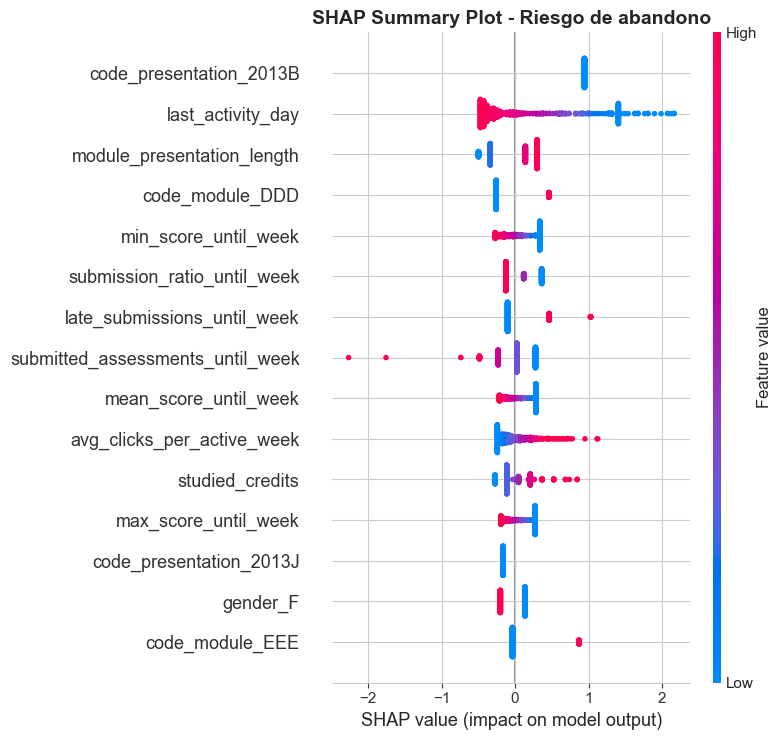

Top 10 variables por importancia SHAP:


,mean_abs_SHAP
code_presentation_2013B,0.943021
last_activity_day,0.570888
module_presentation_length,0.289457
code_module_DDD,0.286566
min_score_until_week,0.209741
submission_ratio_until_week,0.196700
late_submissions_until_week,0.184619
submitted_assessments_until_week,0.176593
mean_score_until_week,0.176171
avg_clicks_per_active_week,0.171821


Interpretacion:
- Valores SHAP positivos empujan la prediccion hacia abandono.
- Valores SHAP negativos empujan la prediccion hacia permanencia.
- Las variables tempranas permiten justificar alertas antes de que termine el curso.


In [140]:
# SHAP SUMMARY PLOT

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_class, X_test_sample_plot, show=False, max_display=15)
plt.title('SHAP Summary Plot - Riesgo de abandono', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

feature_importance_shap = pd.Series(
    np.abs(shap_values_class).mean(axis=0),
    index=X_test_sample.columns
).sort_values(ascending=False)

print("Top 10 variables por importancia SHAP:")
display(feature_importance_shap.head(10).to_frame('mean_abs_SHAP'))

print("Interpretacion:")
print("- Valores SHAP positivos empujan la prediccion hacia abandono.")
print("- Valores SHAP negativos empujan la prediccion hacia permanencia.")
print("- Las variables tempranas permiten justificar alertas antes de que termine el curso.")

Top features para dependence plots: ['code_presentation_2013B', 'last_activity_day', 'module_presentation_length', 'code_module_DDD']


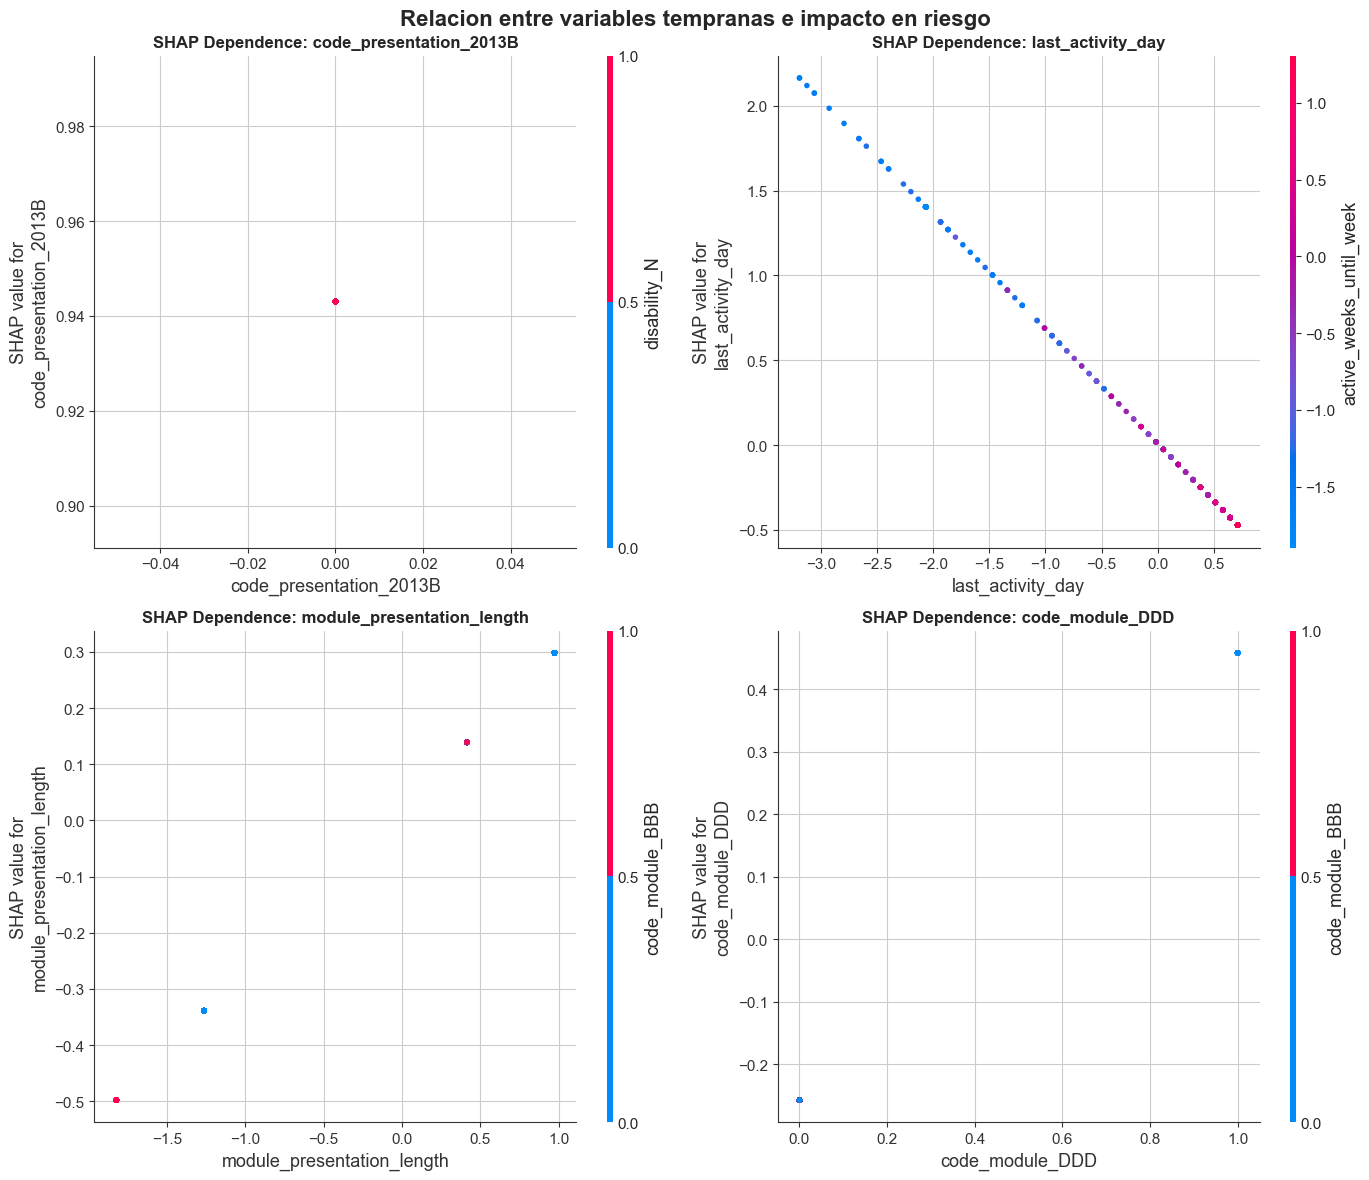

In [141]:
# SHAP DEPENDENCE PLOTS

top_features_names = feature_importance_shap.head(4).index.tolist()
print(f"Top features para dependence plots: {top_features_names}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features_names):
    shap.dependence_plot(feature, shap_values_class, X_test_sample_plot, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence: {feature}', fontsize=12, fontweight='bold')

plt.suptitle('Relacion entre variables tempranas e impacto en riesgo', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


CASO: Abandono detectado correctamente (TP)
Probabilidad estimada de abandono: 0.952


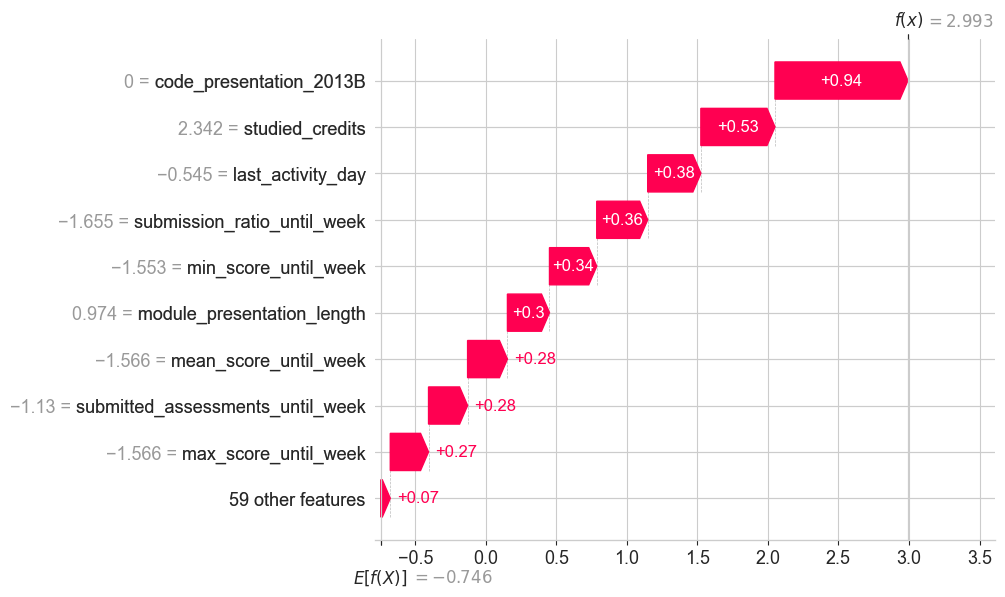


CASO: No abandono detectado correctamente (TN)
Probabilidad estimada de abandono: 0.325


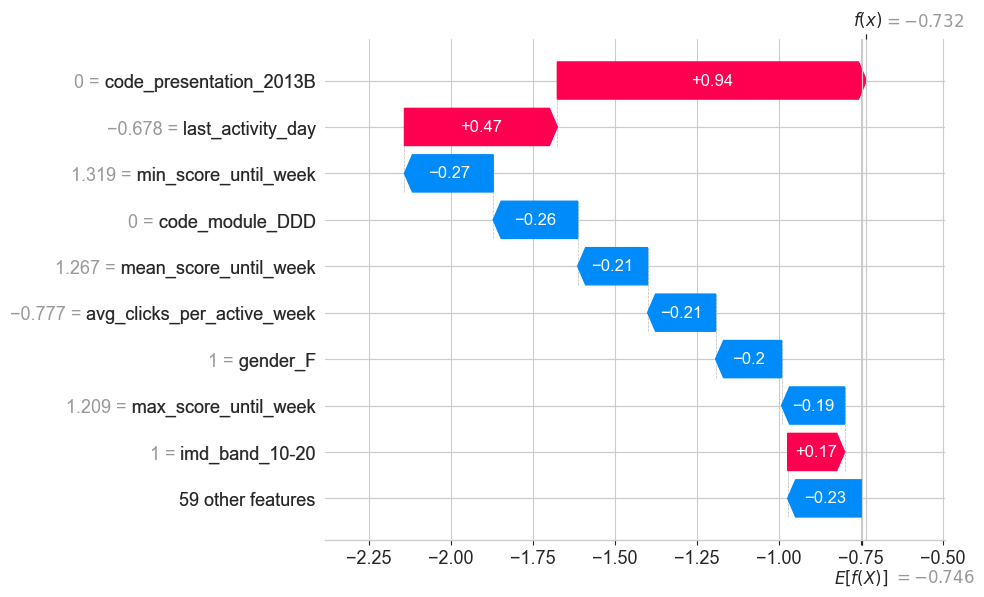


CASO: Abandono no detectado (FN)
Probabilidad estimada de abandono: 0.956


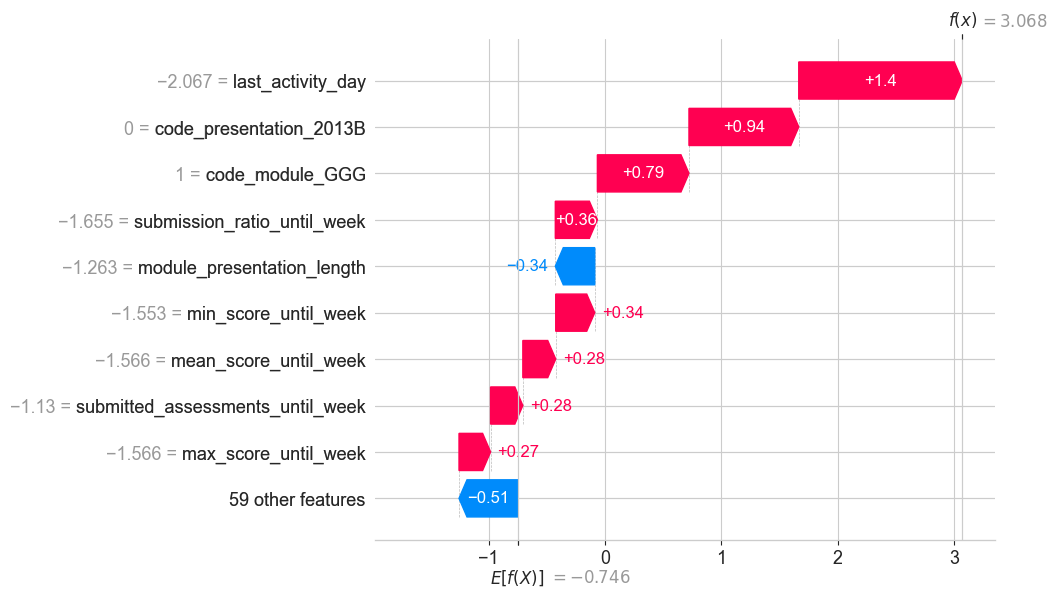

Utilidad para el cliente:
La institucion no solo recibe una alerta, sino una explicacion accionable: baja actividad, pocas entregas, caida reciente de engagement u otros factores observables.


In [143]:
# SHAP: EXPLICACION INDIVIDUAL PARA CASOS REPRESENTATIVOS

true_positives = np.where((y_test_sample.values == 1) & (y_pred_sample == 1))[0]
true_negatives = np.where((y_test_sample.values == 0) & (y_pred_sample == 0))[0]
false_negatives = np.where((y_test_sample.values == 1) & (y_pred_sample == 0))[0]

examples = []

if len(true_positives) > 0:
    examples.append(('Abandono detectado correctamente (TP)', true_positives[0]))

if len(true_negatives) > 0:
    examples.append(('No abandono detectado correctamente (TN)', true_negatives[0]))

if len(false_negatives) > 0:
    examples.append(('Abandono no detectado (FN)', false_negatives[0]))

for title, idx in examples[:3]:
    case_proba = estimator.predict_proba(X_test_sample.iloc[[idx]])[0, 1]

    print()
    print(f"{'='*60}")
    print(f"CASO: {title}")
    print(f"Probabilidad estimada de abandono: {case_proba:.3f}")
    print(f"{'='*60}")

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_class[idx],
            base_values=expected_value,
            data=X_test_sample_plot.iloc[idx].values,
            feature_names=X_test_sample.columns.tolist()
        ),
        max_display=10,
        show=True
    )

print("Utilidad para el cliente:")
print("La institucion no solo recibe una alerta, sino una explicacion accionable: baja actividad, pocas entregas, caida reciente de engagement u otros factores observables.")

---
## SECCION 11: Recomendaciones, Limitaciones y Conclusiones

### Recomendaciones para una institucion educativa

1. Priorizar alertas tempranas en semanas 2, 4 y 6 para orientar tutorias antes de que el abandono sea irreversible.
2. Usar el **recall** como metrica de operacion principal: es preferible revisar algunos falsos positivos antes que perder estudiantes realmente en riesgo.
3. Combinar la prediccion con explicaciones SHAP para decidir intervenciones concretas: contacto docente, apoyo academico, seguimiento de actividad o revision de entregas.
4. Revisar periodicamente el desempeño por cohortes, porque el comportamiento de estudiantes puede cambiar entre presentaciones.

### Limitaciones

- OULAD pertenece a una institucion y contexto especificos; la generalizacion a otras universidades requiere validacion externa.
- Las interacciones en plataforma no capturan toda la realidad del estudiante: trabajo, salud, conectividad o motivacion pueden quedar fuera.
- Los snapshots semanales simplifican la temporalidad; una implementacion productiva podria usar ventanas mas finas.
- El sistema apoya decisiones humanas, no reemplaza criterio pedagogico.

### Trabajo futuro

- Incorporar calibracion de probabilidades y umbrales definidos con la institucion.
- Evaluar intervenciones reales y medir si las alertas reducen abandono.
- Explorar modelos temporales mas avanzados solo despues de estabilizar el enfoque simple.
- Desplegar un tablero operativo para seguimiento de cohortes.

### Conclusion

El proyecto queda planteado como un **sistema inteligente de alerta temprana de abandono estudiantil**. La mejora central no es usar un modelo mas complejo, sino construir una metodologia defendible: evitar leakage, evaluar con split temporal, comparar modelos con criterio e interpretar las predicciones para convertirlas en acciones educativas.

---
## Uso de Inteligencia Artificial Generativa

Durante el desarrollo de este proyecto se utilizaron herramientas de inteligencia artificial generativa como asistencia en diversas etapas del proceso. A continuación se detalla para qué se utilizó y cómo se integró críticamente:

### Herramientas utilizadas

Se emplearon modelos de lenguaje (LLMs) como parte del proceso de desarrollo.

### Aplicaciones

1. **Generación de código boilerplate**: Se utilizó IA para generar el esqueleto inicial del notebook, incluyendo la estructura de celdas y las importaciones de librerías. Todo el código generado fue revisado y modificado para asegurar su correcto funcionamiento con el dataset específico.

2. **Sugerencias de visualización**: La IA propuso tipos de gráficos apropiados para distintos tipos de análisis (radar charts para perfiles, dependence plots para SHAP). Se evaluó cada sugerencia y se adaptó al contexto del problema.

3. **Documentación técnica**: Ayudó en la redacción de las explicaciones conceptuales de cada sección y en la generación de la estructura del README y ROADMAP.

4. **Debugging**: Se utilizó para identificar y corregir errores en el código de preprocesamiento, particularmente en la integración de las tablas del dataset y el feature engineering.

### Revisión crítica

Todas las decisiones de diseño del sistema fueron tomadas por el equipo: la selección del problema (predicción de abandono), la elección de los modelos a comparar, la definición de las métricas de evaluación, el preprocesamiento de los datos y la interpretación de los resultados. La IA se utilizó como herramienta de asistencia, no como sustituto del criterio del equipo. Cada fragmento de código generado fue revisado, comprendido y, cuando fue necesario, modificado para alinearse con los objetivos del proyecto y las buenas prácticas de Machine Learning.

---

*Proyecto desarrollado para la materia Sistemas Inteligentes — 2026*